In [1]:
import os
import sys
#import glasbey
import gc
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import anndata as ad
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu
import umap
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, average_precision_score

import networkx as nx
from scipy.stats import spearmanr
import matplotlib.colors as mcolors
from adjustText import adjust_text

dir = '/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/PythonIMC'
sys.path.append(os.path.abspath(dir))
from pythonimc import assembling#, plotting

base_dir = '/Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis'

In [2]:
# Read in data
data = ad.read_h5ad('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/12012025_annotdata.h5ad')

cols_to_drop = [
    'BMI', 'Race', 'Sex', 'Birthyear', 'DOS', 'Age', 'Location', 'Diameter', 
    'Thickness', 'Grade', 'OtherInvolvement', 'L', 'Pn', 'PN', 'Npos', 'Nres', 
    'PT', 'Smoking', 'Alcohol', 'Outcome', 'Recurrence_date', 'Time_to_recurrence', 
    'Recurrence_3yrs', 'Recurrence_5yrs', 'Recurrence_overall', 'Death_date', 
    'Time_to_death', 'Mortality', 'Last_followup', 'PFS', 'Death_cause', 
    'Death_cancerrelated', 'Comorbidities', 'GI_disease', 'Psychiatric_disorder', 
    'Seizures', 'Lung_disease', 'Parkinsons', 'Liver_disease', 'Kidney_disease', 
    'Rheumatoid_arthritis', 'Transplant_history', 'Cardiovascular_disease', 
    'Thyroid_diasease', 'HTN', 'Other_cancer', 'Asthma', 'Diabetes', 'CTX', 'RTX', 
    'Birthdate', 'CT', 'CN', 'CM', 'V', 'R', 'Chemotherapy', 'Radiation'
]

# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in data.obs.columns]
data.obs = data.obs.drop(columns=cols_to_drop)

#print(f"Dropped {len(cols_to_drop)} columns. Remaining: {data.obs.shape[1]}")
data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['Outcomes_Stanford.xlsx','Outcomes_Tubingen.xlsx'], merge_on_column="Casenumber")

In [3]:
# Color scheme

CLUSTER_COLORS = {
    'D': '#467F82',   # TumorNonproliferating — teal
    'T': '#E5875D',   # CD8Tcells — warm orange
    'G': '#851E14',   # Granulocytes — deep red/burgundy
    'S': '#95D1D3',   # TumorSOX9+ — light teal
}

# ── Color families ──────────────────────────────────────────────
# TUMOR (teals, anchored to clusters 0 & 3)
# CD8 T (oranges/ambers, anchored to cluster 1)
# CD4 T (blues)
# MACRO/MONO + DCs (warm browns/tans)
# GRANULOCYTES (burgundy/wine, anchored to cluster 2)
# FIBROBLASTS / SM / NERVE (muted greens)
# VESSELS / LYMPHATICS (pinks/mauves)
# B CELLS / NK CELLS (gold/yellow family)
# OTHER (single gray)

COLOR_MAP = {
    # ── Tumor (teal family) ──────────────────────────────────────
    'TumorNonproliferating':  '#467F82',   # cluster 0 anchor — unchanged
    'TumorSOX9+':             '#95D1D3',   # cluster 3 anchor — unchanged
    'TumorKi67+':             '#1D5C60',   # rich dark teal
    'TumorKi67+SOX9+':        '#5BBFC5',   # vivid mid teal
    'TumorpMK2+':             '#C8EDEF',   # bright ice teal

    # ── CD8 T cells (orange/amber family) ───────────────────────
    'CD8Tcells':              '#E5875D',   # cluster 1 anchor — unchanged
    'CD8Teff':                '#C04A18',   # vivid burnt orange
    'CD8Tmemory':             '#F5A66D',   # bright peach
    'CD8Tnaive':              '#FCCDA4',   # light but clean peach
    'CD8Ttrmlike':            '#8C3010',   # deep vivid sienna

    # ── CD4 T cells (blue family) ────────────────────────────────
    'CD4Tcells':              "#003BB2",   # vivid steel blue
    'CD4Tmemory':             '#1A4BBF',   # strong cobalt
    'CD4Tregs':               '#6A9FEE',   # bright periwinkle
    'CD4Tfh':                 '#A0C4F8',   # clear sky blue
    'CD4Tnaive':              '#0D2D8A',   # deep electric navy

    # ── Macro/Mono + DCs (warm brown/tan family) ─────────────────
    'Macro/Mono':             "#FFBF00",   # vivid amber
    'M1Macro':                '#9C3F08',   # rich mahogany
    'M2Macro':                '#E8A040',   # bright golden amber
    'M2MacroCD209+':          '#F5C96A',   # vivid warm yellow
    'Monocytes':              '#B05E18',   # strong copper
    'DCs':                    '#FAE0A0',   # bright straw

    # ── Granulocytes (burgundy/wine family) ──────────────────────
    'Granulocytes':           '#851E14',   # cluster 2 anchor — unchanged

    # ── Fibroblasts / SM / Nerve (muted green family) ────────────
    'FibroblastsTenC+':       '#2E8B4A',   # vivid forest green
    'SM':                     '#6DC483',   # bright sage
    'Nerve':                  '#AEEABC',   # bright mint

    # ── Vessels / Lymphatics (pink/mauve family) ─────────────────
    'Vessel':                 '#D4568A',   # vivid rose
    'Arteriole':              '#A8184E',   # bright deep magenta
    'Capillary':              '#F08AB8',   # bright pink
    'Lymphatics':             '#F7C0D8',   # clean light pink

    # ── B cells / NK cells (gold/yellow family) ──────────────────
    'Bcells':                 "#815FCB",   # dark gold — unchanged
    'NKcells':                '#F5C242',   # warm yellow — unchanged

    # ── Other ────────────────────────────────────────────────────
    'Other':                  '#C7C7C7',   # single gray — unchanged
}

# Clinical baseline

NAs per column (n casenumbers):
PFS                     7
Recurrence_3yrs         7
Mortality               0
Time_to_death         136
Recurrence_overall      7
dtype: int64

Total casenumbers: 195
Group sizes:
Recurrence_3yrs
0.0    142
1.0     46
Name: count, dtype: int64


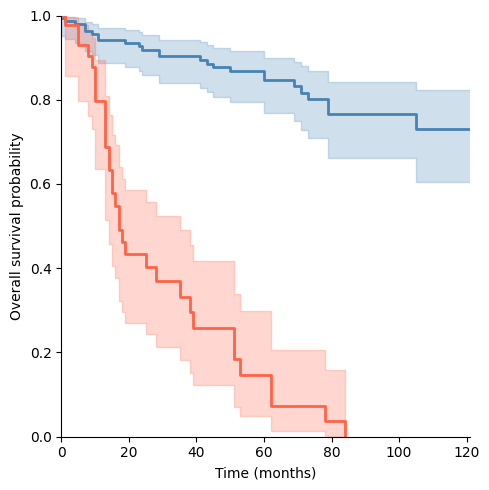

In [4]:
# Survival analysis by 3-year recurrence status
km_cols = ['Casenumber', 'PFS', 'Recurrence_3yrs', 'Mortality', 'Time_to_death', 'Recurrence_overall']

km_data = (data.obs[km_cols]
    .drop_duplicates(subset='Casenumber')
    .set_index('Casenumber')
    .dropna(subset=['Mortality']))

km_data_raw = (data.obs[km_cols]
    .drop_duplicates(subset='Casenumber')
    .set_index('Casenumber'))

print("NAs per column (n casenumbers):")
print(km_data_raw.isna().sum())
print(f"\nTotal casenumbers: {len(km_data_raw)}")

km_data['PFS'] = pd.to_numeric(km_data['PFS'], errors='coerce')
km_data['Time_to_death'] = pd.to_numeric(km_data['Time_to_death'], errors='coerce')
km_data['Recurrence_3yrs'] = pd.to_numeric(km_data['Recurrence_3yrs'], errors='coerce')
km_data['Mortality'] = km_data['Mortality'].fillna(0).astype(int)

km_data['OS_time'] = km_data['Time_to_death'].fillna(km_data['PFS'])
km_data['OS_event'] = km_data['Mortality']

km_data = km_data.dropna(subset=['OS_time', 'Recurrence_3yrs'])

print("Group sizes:")
print(km_data['Recurrence_3yrs'].value_counts())

fig, ax = plt.subplots(figsize=(5, 5))
kmf = KaplanMeierFitter()

groups = {0.0: ('No recurrence', 'steelblue'),
          1.0: ('Recurrence', 'tomato')}

for group, (label, color) in groups.items():
    mask = km_data['Recurrence_3yrs'] == group
    kmf.fit(
        km_data.loc[mask, 'OS_time'],
        event_observed=km_data.loc[mask, 'OS_event'],
        label=label
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2)

lr = logrank_test(
    km_data.loc[km_data['Recurrence_3yrs'] == 0.0, 'OS_time'],
    km_data.loc[km_data['Recurrence_3yrs'] == 1.0, 'OS_time'],
    event_observed_A=km_data.loc[km_data['Recurrence_3yrs'] == 0.0, 'OS_event'],
    event_observed_B=km_data.loc[km_data['Recurrence_3yrs'] == 1.0, 'OS_event']
)

#ax.set_title(f'Overall survival by 3-year recurrence\np = {lr.p_value:.3f}')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Overall survival probability')
ax.set_ylim(0, 1)
ax.set_xlim(0,121)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "tmp", "survival_by_recurrence.pdf"), bbox_inches='tight')
plt.show()

# Figure 3a

n=188, recurrence rate=0.24
Class balance: {0: 142, 1: 46}
Features after encoding: 18
Remaining NAs: 0


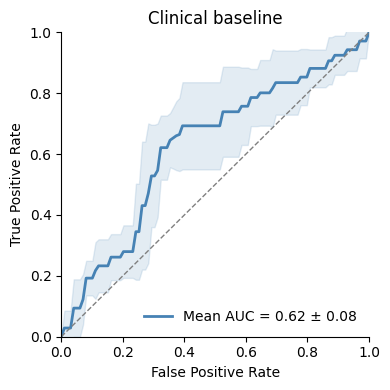

Per-fold AUCs: ['0.646', '0.525', '0.664', '0.731', '0.552']
Mean AUC: 0.624 ± 0.075
AUPRC:  0.381 ± 0.058
Baseline AUPRC (random): 0.245


In [5]:
# --- Build clinical feature matrix ---
clinical_cols    = ['PT', 'PN', 'Pn', 'L', 'Grade', 'Sex', 'Age']
numerical_cols   = ['Age', 'Grade', 'Pn', 'L']
categorical_cols = ['Sex',  'PT', 'PN']

clin = (
    data.obs[clinical_cols + ['Casenumber', 'Recurrence_3yrs']]
    .drop_duplicates(subset='Casenumber')
    .set_index('Casenumber')
)
clin['Recurrence_3yrs'] = pd.to_numeric(clin['Recurrence_3yrs'], errors='coerce')
clin = clin.dropna(subset=['Recurrence_3yrs'])

# --- Impute before encoding ---
num_imputer = SimpleImputer(strategy='median')
clin_num = pd.DataFrame(
    num_imputer.fit_transform(clin[numerical_cols]),
    columns=numerical_cols,
    index=clin.index
)

cat_imputer = SimpleImputer(strategy='most_frequent')
clin_cat_imputed = pd.DataFrame(
    cat_imputer.fit_transform(clin[categorical_cols].astype(str).replace('nan', np.nan)),
    columns=categorical_cols,
    index=clin.index
)

clin_encoded = pd.get_dummies(clin_cat_imputed, drop_first=False)
X_clin       = pd.concat([clin_num, clin_encoded], axis=1).astype(float)
y            = clin['Recurrence_3yrs'].astype(int)

print(f"n={len(y)}, recurrence rate={y.mean():.2f}")
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"Features after encoding: {X_clin.shape[1]}")
print(f"Remaining NAs: {X_clin.isna().sum().sum()}")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

groups = clin.index  # Casenumber — ensures patient-level splits
cv     = StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True)

fig, ax = plt.subplots(figsize=(4, 4))

fold_aucs = []
fold_auprcs =[]
all_fpr   = np.linspace(0, 1, 100)
mean_tprs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_clin, y, groups)):
    X_train, X_test = X_clin.iloc[train_idx], X_clin.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fold_auc = auc(fpr, tpr)
    fold_aucs.append(fold_auc)

    # Inside the fold loop, after y_prob:
    fold_auprc = average_precision_score(y_test, y_prob)
    fold_auprcs.append(fold_auprc)

    interp_tpr    = np.interp(all_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    mean_tprs.append(interp_tpr)

mean_tpr      = np.mean(mean_tprs, axis=0)
mean_tpr[-1]  = 1.0
mean_auc      = np.mean(fold_aucs)
std_auc       = np.std(fold_aucs)
std_tpr       = np.std(mean_tprs, axis=0)
mean_auprc = np.mean(fold_auprcs)
std_auprc = np.std(fold_auprcs)

ax.plot(all_fpr, mean_tpr, color='steelblue', linewidth=2,
        label=f'Mean AUC = {mean_auc:.2f} ± {std_auc:.2f}')
ax.fill_between(all_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                alpha=0.15, color='steelblue')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Clinical baseline')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'tmp', 'clinical_baseline_AUC.pdf'), bbox_inches='tight')
plt.show()

print(f"Per-fold AUCs: {[f'{a:.3f}' for a in fold_aucs]}")
print(f"Mean AUC: {mean_auc:.3f} ± {std_auc:.3f}")
print(f"AUPRC:  {mean_auprc:.3f} ± {std_auprc:.3f}")
print(f"Baseline AUPRC (random): {y.mean():.3f}")

In [6]:
data.obs = data.obs.loc[:, ~data.obs.columns.duplicated(keep='last')]
mask = (data.obs['Tumorborder'] >= 10_000) & (data.obs['Recurrence_3yrs'].notna())
mask = mask.fillna(False).astype(bool)
data = data[mask]
gc.collect()

6609

# Clustering

In [ ]:
# Clustering WITHOUT batch correction
def run_clustering_without_batchcorrection(data_obs, level='patient', n_clusters=4, n_init=1000,
                   n_neighbors=15, min_dist=0.3, random_state=42,
                   show_elbow=True, show_boxplot=True):
    """
    Run frequency-based KMeans clustering + UMAP at patient or image level.
    
    Parameters
    ----------
    data_obs   : data.obs (AnnData observation dataframe)
    level      : 'patient' (group by Casenumber) or 'image' (group by Casenumber + Image)
    n_clusters : number of KMeans clusters
    n_init     : number of KMeans initializations
    
    Returns
    -------
    umap_df    : DataFrame with UMAP1, UMAP2, Cluster, Outcome — indexed by Casenumber or Image
    freq_wide  : raw frequency matrix used for clustering
    kmeans     : fitted KMeans object
    selector   : fitted VarianceThreshold object
    imputer    : fitted SimpleImputer object
    """
    
    index_cols = ['Casenumber'] if level == 'patient' else ['Casenumber', 'Image']
    
    # --- Build frequency matrix ---
    counts = (
        data_obs
        .query('Subtype != "Other"')
        .groupby(index_cols + ['Sector', 'Subtype'])
        .size()
        .reset_index(name='Count')
    )
    
    total_per_zone = (
        counts
        .query('Subtype != "Other"')
        .groupby(index_cols + ['Sector'])['Count']
        .sum()
        .reset_index(name='Total_excl_Other')
    )
    
    freq_df = counts.merge(total_per_zone, on=index_cols + ['Sector'], how='left')
    freq_df['Frequency'] = freq_df['Count'] / freq_df['Total_excl_Other'] * 100
    
    freq_wide = freq_df.pivot_table(
        index=index_cols,
        columns=['Subtype', 'Sector'],
        values='Frequency',
        fill_value=0
    )
    freq_wide.columns = [f"{subtype}_{sector}_freq" for subtype, sector in freq_wide.columns]
    print(f"[{level}] freq_wide shape: {freq_wide.shape}")
    
    # --- Preprocess ---
    X = freq_wide.copy()
    X = X[[c for c in X.columns if 'Other' not in c]]
    
    selector = VarianceThreshold(threshold=0)
    X_sel = selector.fit_transform(X)
    
    imputer = SimpleImputer(strategy='median')
    X_imp = imputer.fit_transform(X_sel)
    print(f"[{level}] X shape after preprocessing: {X_imp.shape}")
    
    # --- Elbow plot ---
    if show_elbow:
        inertia = []
        for k in range(2, 20):
            km = KMeans(n_clusters=k, random_state=random_state).fit(X_imp)
            inertia.append(km.inertia_)
        plt.figure(figsize=(6, 3))
        plt.plot(range(2, 20), inertia, '-o')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Inertia')
        plt.title(f'Elbow method — {level} level')
        plt.tight_layout()
        plt.show()
    
    # --- KMeans ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    sample_labels = kmeans.fit_predict(X_imp)
    
    # --- UMAP ---
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
    embedding = reducer.fit_transform(X_imp)
    
    # --- Build umap_df ---
    umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
    umap_df['Cluster'] = sample_labels
    umap_df.index = freq_wide.index
    
    # Map outcome — always at Casenumber level
    outcome = data_obs.groupby('Casenumber')['Recurrence_3yrs'].first()
    if level == 'patient':
        umap_df['Outcome'] = umap_df.index.map(outcome)
    else:
        casenumber = umap_df.index.get_level_values('Casenumber')
        umap_df['Casenumber'] = casenumber
        umap_df['Outcome'] = casenumber.map(outcome)
    
    print(f"\n[{level}] Cluster sizes:")
    print(umap_df['Cluster'].value_counts().sort_index())
    print(f"\n[{level}] Cluster × Outcome:")
    print(umap_df.groupby('Cluster')['Outcome'].value_counts())
    
    # --- Top discriminating features boxplot ---
    if show_boxplot:
        d = freq_wide.copy()
        cluster_means = d.assign(Cluster=umap_df['Cluster']).groupby('Cluster').mean()
        top_features = cluster_means.var(axis=0).sort_values(ascending=False).head(20).index
        long_df = (
            d.assign(Cluster=umap_df['Cluster'])
            .melt(id_vars='Cluster', value_vars=top_features,
                  var_name='Feature', value_name='Value')
        )
        plt.figure(figsize=(12, 5))
        sns.boxplot(data=long_df, x='Feature', y='Value', hue='Cluster',
                    palette=CLUSTER_COLORS)
        plt.xticks(rotation=90)
        plt.title(f'Top discriminating features — {level} level')
        plt.tight_layout()
        plt.show()
    
    return umap_df, freq_wide, kmeans, selector, imputer

In [7]:
# Clustering with batch correction

def combat_simple(X, batch):
    """
    Simple mean-centering batch correction.
    Fits a linear model per feature ~ batch and removes batch effect.
    """
    from sklearn.preprocessing import LabelEncoder
    import pandas as pd
    
    le = LabelEncoder()
    batch_encoded = le.fit_transform(batch)
    
    # One-hot encode batch
    n_batches = len(np.unique(batch_encoded))
    batch_onehot = np.zeros((len(batch_encoded), n_batches))
    for i, b in enumerate(batch_encoded):
        batch_onehot[i, b] = 1

    X_corrected = X.copy().astype(float)
    
    for j in range(X.shape[1]):
        reg = LinearRegression(fit_intercept=True).fit(batch_onehot, X[:, j])
        batch_effect = reg.predict(batch_onehot) - reg.intercept_
        X_corrected[:, j] = X[:, j] - batch_effect
    
    return X_corrected


def run_clustering(data_obs, level='patient', n_clusters=4, n_init=1000,
                   n_neighbors=15, min_dist=0.3, random_state=42,
                   show_elbow=True, show_boxplot=True,
                   batch_correct=True, batch_col='TMA'):
    
    index_cols = ['Casenumber'] if level == 'patient' else ['Casenumber', 'Image']
    
    # --- Build frequency matrix ---
    counts = (
        data_obs
        .query('Subtype != "Other"')
        .groupby(index_cols + ['Sector', 'Subtype'])
        .size()
        .reset_index(name='Count')
    )
    
    total_per_zone = (
        counts
        .groupby(index_cols + ['Sector'])['Count']
        .sum()
        .reset_index(name='Total_excl_Other')
    )
    
    freq_df = counts.merge(total_per_zone, on=index_cols + ['Sector'], how='left')
    freq_df['Frequency'] = freq_df['Count'] / freq_df['Total_excl_Other'] * 100
    
    freq_wide = freq_df.pivot_table(
        index=index_cols,
        columns=['Subtype', 'Sector'],
        values='Frequency',
        fill_value=0
    )
    freq_wide.columns = [f"{subtype}_{sector}_freq" for subtype, sector in freq_wide.columns]
    print(f"[{level}] freq_wide shape: {freq_wide.shape}")
    
    # --- Preprocess ---
    X = freq_wide.copy()
    X = X[[c for c in X.columns if 'Other' not in c]]
    
    selector = VarianceThreshold(threshold=0)
    X_sel = selector.fit_transform(X)
    
    imputer = SimpleImputer(strategy='median')
    X_imp = imputer.fit_transform(X_sel)
    print(f"[{level}] X shape after preprocessing: {X_imp.shape}")
    
    if batch_correct:
        batch_meta = (
            data_obs.groupby(index_cols)[batch_col]
            .first()
            .reindex(freq_wide.index)
            .values
        )
        X_cluster = combat_simple(X_imp, batch_meta)
        print(f"[{level}] Simple linear batch correction applied on {batch_col}")
    else:
        X_cluster = X_imp

    # --- Elbow plot ---
    if show_elbow:
        inertia = []
        for k in range(2, 20):
            km = KMeans(n_clusters=k, random_state=random_state).fit(X_cluster)
            inertia.append(km.inertia_)
        plt.figure(figsize=(6, 3))
        plt.plot(range(2, 20), inertia, '-o')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Inertia')
        plt.title(f'Elbow method — {level} level')
        plt.tight_layout()
        plt.show()
    
    # --- KMeans ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    sample_labels = kmeans.fit_predict(X_cluster)
    
    # --- UMAP on batch-corrected matrix ---
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
    embedding = reducer.fit_transform(X_cluster)
    
    # --- Build umap_df ---
    umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
    umap_df['Cluster'] = sample_labels
    umap_df.index = freq_wide.index
    
    # Map outcome
    outcome = data_obs.groupby('Casenumber')['Recurrence_3yrs'].first()
    if level == 'patient':
        umap_df['Outcome'] = umap_df.index.map(outcome)
    else:
        casenumber = umap_df.index.get_level_values('Casenumber')
        umap_df['Casenumber'] = casenumber
        umap_df['Outcome'] = casenumber.map(outcome)
    
    print(f"\n[{level}] Cluster sizes:")
    print(umap_df['Cluster'].value_counts().sort_index())
    print(f"\n[{level}] Cluster × Outcome:")
    print(umap_df.groupby('Cluster')['Outcome'].value_counts())
    
    # --- Top discriminating features boxplot ---
    if show_boxplot:
        d = freq_wide.copy()
        cluster_means = d.assign(Cluster=umap_df['Cluster']).groupby('Cluster').mean()
        top_features = cluster_means.var(axis=0).sort_values(ascending=False).head(20).index
        long_df = (
            d.assign(Cluster=umap_df['Cluster'])
            .melt(id_vars='Cluster', value_vars=top_features,
                  var_name='Feature', value_name='Value')
        )
        plt.figure(figsize=(12, 5))
        sns.boxplot(data=long_df, x='Feature', y='Value', hue='Cluster')
        plt.xticks(rotation=90)
        plt.title(f'Top discriminating features — {level} level')
        plt.tight_layout()
        plt.show()
    
    return umap_df, freq_wide, kmeans, selector, imputer

[patient] freq_wide shape: (187, 112)
[patient] X shape after preprocessing: (187, 98)
[patient] Simple linear batch correction applied on TMA


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



[patient] Cluster sizes:
Cluster
0    62
1    40
2     6
3    79
Name: count, dtype: int64

[patient] Cluster × Outcome:
Cluster  Outcome
0        0.0        47
         1.0        15
1        0.0        25
         1.0        15
2        0.0         3
         1.0         3
3        0.0        66
         1.0        13
Name: count, dtype: int64


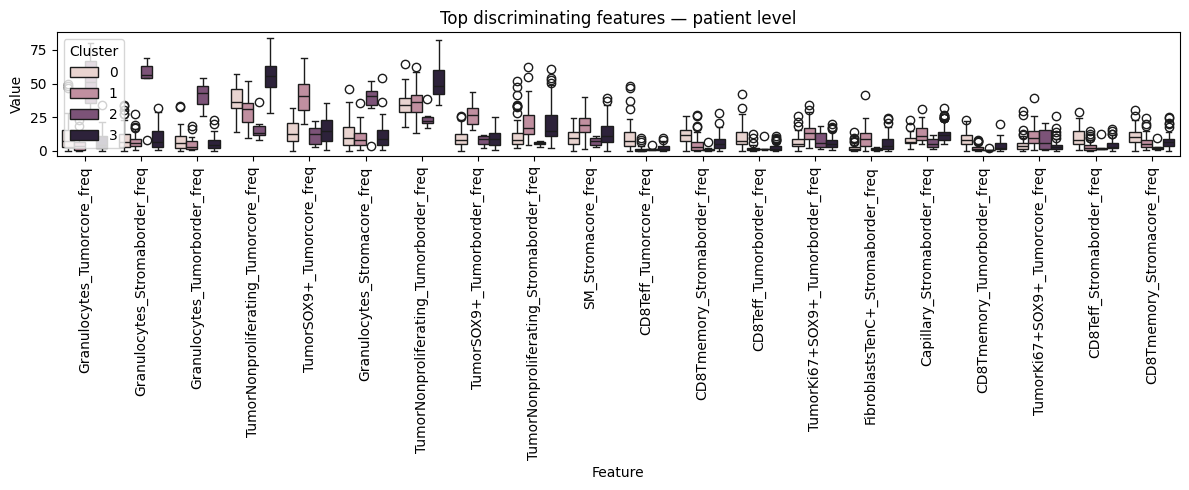

[image] freq_wide shape: (538, 112)
[image] X shape after preprocessing: (538, 98)
[image] Simple linear batch correction applied on TMA

[image] Cluster sizes:
Cluster
0     45
1    231
2    137
3    125
Name: count, dtype: int64

[image] Cluster × Outcome:
Cluster  Outcome
0        0.0         30
         1.0         15
1        0.0        185
         1.0         46
2        0.0        103
         1.0         34
3        0.0         88
         1.0         37
Name: count, dtype: int64


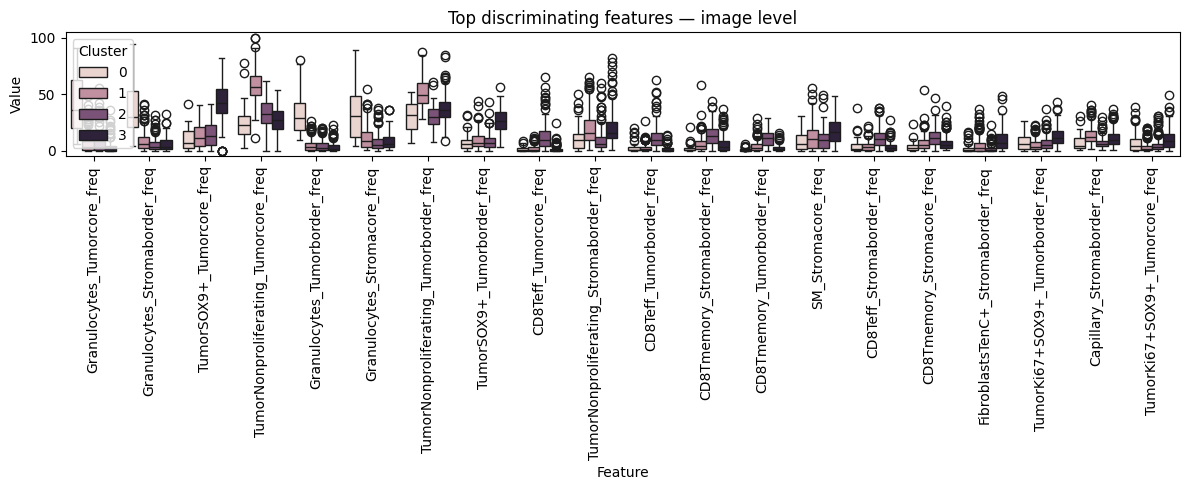

In [8]:
# --- Run at both levels ---
umap_patient, freq_wide_patient, kmeans_patient, selector_patient, imputer_patient = \
    run_clustering(data.obs, level='patient', show_elbow=False)

umap_image, freq_wide_image, kmeans_image, selector_image, imputer_image = \
    run_clustering(data.obs, level='image', show_elbow=False)

patient_remap = {0: 'T', 1: 'S', 2: 'G', 3: 'D'}  # adjust if different from image remap
umap_patient['Cluster'] = umap_patient['Cluster'].map(patient_remap)

image_remap = {0: 'G', 1: 'D', 2: 'T', 3: 'S'}
umap_image['Cluster'] = umap_image['Cluster'].map(image_remap)

cluster_order = ['D', 'G', 'T', 'S']

umap_patient['Cluster'] = pd.Categorical(umap_patient['Cluster'], categories=cluster_order, ordered=True)
umap_image['Cluster'] = pd.Categorical(umap_image['Cluster'], categories=cluster_order, ordered=True)

consistency = umap_image[['Cluster', 'Casenumber']].copy()
consistency = consistency.rename(columns={'Cluster': 'ImageCluster'})
consistency['PatientCluster'] = consistency['Casenumber'].map(umap_patient['Cluster'])
consistency = consistency.dropna(subset=['PatientCluster'])
#consistency['PatientCluster'] = consistency['PatientCluster'].astype(int)

# Phenotyping

In [9]:
# Get one row per image (zonal sizes are the same for all cells in an image)
zone_cols = ['Tumorborder', 'Stromaborder', 'Tumorcore', 'Stromacore']

image_zones = data.obs[['Casenumber'] + zone_cols].drop_duplicates(subset='Casenumber').set_index('Casenumber')
# Normalize each image's zones to fractions (row-wise)
image_zone_fractions = image_zones.div(image_zones.sum(axis=1), axis=0)
mean_zone_fractions = image_zone_fractions.median(axis=0)
print(mean_zone_fractions)

# --- Merge cell types before pivoting ---
celltype_merge = {
    'Macrophages': 'Macro/Mono',
    'Monocytes':   'Macro/Mono',
    'Capillary':   'Vessel',
    'Arteriole':   'Vessel',
}

data.obs['Celltype2'] = data.obs['Celltype'].replace(celltype_merge)

# Count cells per Image, Sector, Subtype
counts = (
    data.obs
    .query('Celltype2 != "Other"')  # 👈 exclude unclassified cells
    .groupby(["Casenumber", "Sector", "Celltype2"])
    .size()
    .reset_index(name="Count")
)

# Compute total cells per image *and zone*
total_per_zone = (
    counts
    .query('Celltype2 != "Other"')  # 👈 exclude unclassified cells
    .groupby(["Casenumber", "Sector"])["Count"]
    .sum()
    .reset_index(name="Total_excl_Other")
)


# Merge and normalize: fraction of each celltype within its zone x image
counts = counts.merge(total_per_zone, on=['Casenumber', 'Sector'])
counts['zone_freq'] = counts['Count'] / counts['Total_excl_Other']
# Normalize zone_freq by the average zone fraction
counts['normalized_freq'] = counts['zone_freq'] * counts['Sector'].astype(str).map(mean_zone_fractions)

# Average normalized_freq across zones for each image x celltype
plot_data = (counts
    .groupby(['Casenumber', 'Celltype2'])['normalized_freq']
    .sum()
    .reset_index())

# --- ADD THIS: normalize so each image sums to 1 ---
plot_data['normalized_freq'] = (
    plot_data.groupby('Casenumber')['normalized_freq']
    .transform(lambda x: x / x.sum())
)

# Pivot to wide format for stacked bar plot
plot_pivot = plot_data.pivot(index='Casenumber', columns='Celltype2', values='normalized_freq')

# # Sort plot_pivot by cluster
plot_pivot = plot_pivot.join(umap_patient['Cluster'])
plot_pivot = plot_pivot.sort_values('Cluster')
cluster_labels = plot_pivot['Cluster']
plot_pivot = plot_pivot.drop(columns='Cluster')

Tumorborder     0.158977
Stromaborder    0.127764
Tumorcore       0.171048
Stromacore      0.513672
dtype: float64


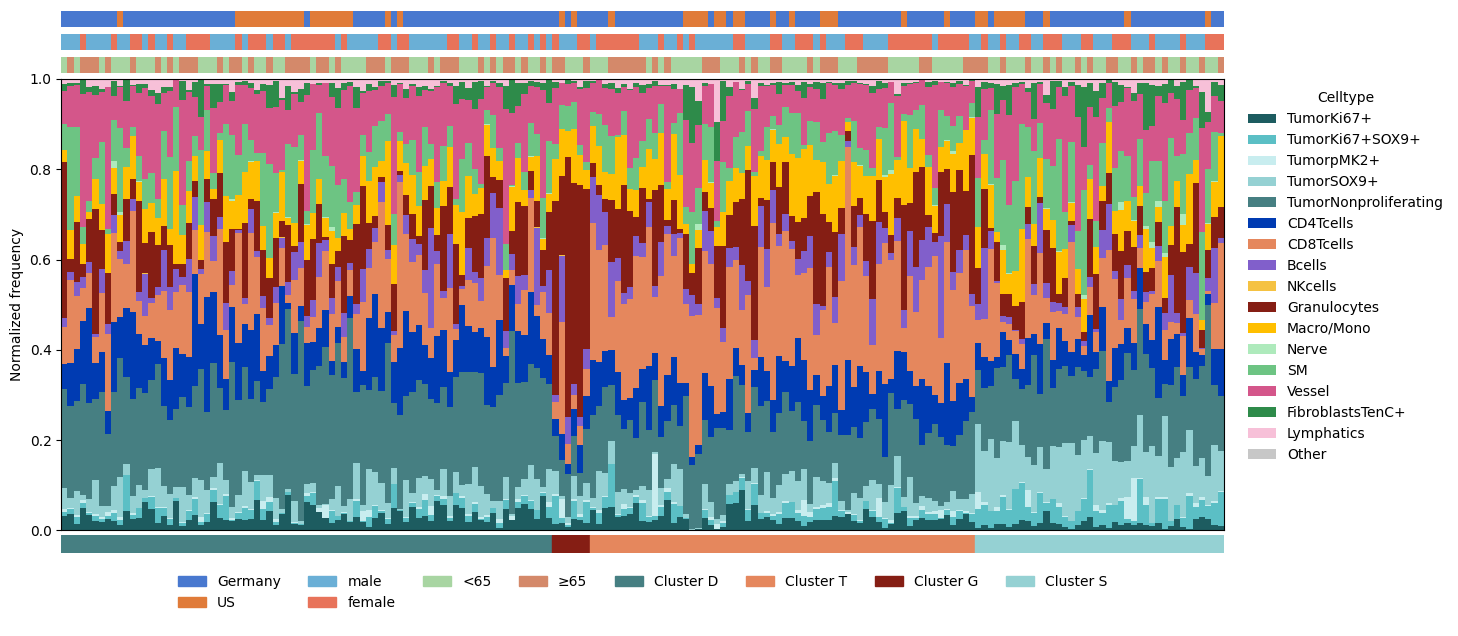

In [10]:
color_ct = [COLOR_MAP.get(ct, '#AAAAAA') for ct in plot_pivot.columns]

# --- Build metadata per Casenumber ---
meta = (
    data.obs[['Casenumber', 'Sex', 'Age']]
    .drop_duplicates('Casenumber')
    .set_index('Casenumber')
)

meta['Cohort'] = pd.Series(meta.index, index=meta.index).str.startswith('K').map({True: 'Germany', False: 'US'})
meta['AgeGroup'] = pd.to_numeric(meta['Age'], errors='coerce').apply(
    lambda x: '≥65' if x >= 65 else '<65'
)

# align to plot_pivot order
meta = meta.loc[plot_pivot.index]

# --- Colors ---
cohort_colors = {'Germany': '#4878CF', 'US':     '#E07B39'}
sex_colors    = {'male':    '#6AAFD6', 'female': '#E8735A'}
age_colors    = {'<65':     '#A8D5A2', '≥65':    '#D4896A'}
cluster_ids    = sorted(cluster_labels.unique())
cluster_colors = CLUSTER_COLORS

def make_annotation_bar(ax, series, color_map):
    for x, val in enumerate(series):
        ax.barh(0, 1, left=x, color=color_map.get(val, 'grey'), height=1)
    ax.set_xlim(0, len(series))
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

cluster_changes = cluster_labels.ne(cluster_labels.shift()).to_numpy().nonzero()[0]

fig, axes = plt.subplots(
    6, 1, figsize=(15, 8),
    gridspec_kw={'height_ratios': [0.04, 0.04, 0.04, 1, 0.04, 0.15], 'hspace': 0.05}
)
ax_cohort, ax_sex, ax_age, ax_main, ax_cluster, ax_legend = axes

# --- Annotation bars (top) ---
make_annotation_bar(ax_cohort, meta['Cohort'],   cohort_colors)
make_annotation_bar(ax_sex,    meta['Sex'],       sex_colors)
make_annotation_bar(ax_age,    meta['AgeGroup'],  age_colors)

# --- Stacked bar (main) ---
plot_pivot.plot(kind='bar', stacked=True, ax=ax_main, color=color_ct, width=1.0)
ax_main.set_xlim(-0.5, len(cluster_labels) - 0.5)
ax_main.set_ylim(0, 1)
ax_main.set_xlabel('')
ax_main.set_ylabel('Normalized frequency')
ax_main.set_xticks([])
ax_main.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, title='Celltype')

# --- Cluster bar (bottom) ---
for i, pos in enumerate(cluster_changes):
    end = cluster_changes[i+1] if i+1 < len(cluster_changes) else len(cluster_labels)
    cluster_id = cluster_labels.iloc[pos]
    ax_cluster.axvspan(pos, end, color=cluster_colors[cluster_id])
ax_cluster.set_xlim(0, len(cluster_labels))
ax_cluster.axis('off')

# --- Legend bar for annotations ---
ax_legend.axis('off')
handles = []
for label, color in {**cohort_colors, **sex_colors, **age_colors, 
                     **{f'Cluster {k}': v for k, v in cluster_colors.items()}}.items():
    handles.append(plt.Rectangle((0,0), 1, 1, color=color, label=label))
ax_legend.legend(handles=handles, loc='center', ncol=8, frameon=False,
                 bbox_to_anchor=(0.5, 0.5))

plt.savefig(os.path.join(base_dir, "tmp", "zone_normalized_composition_by_cluster.pdf"), 
            bbox_inches='tight')
plt.show()

Event counts per cluster:
         n_recurred  n_total      rate
Cluster                               
D                21       78  0.269231
T                23       62  0.370968
S                18       40  0.450000

Pairwise log-rank p-values:
Cluster A Cluster B  p-value
        D         T 0.197796
        D         S 0.007875
        T         S 0.203883


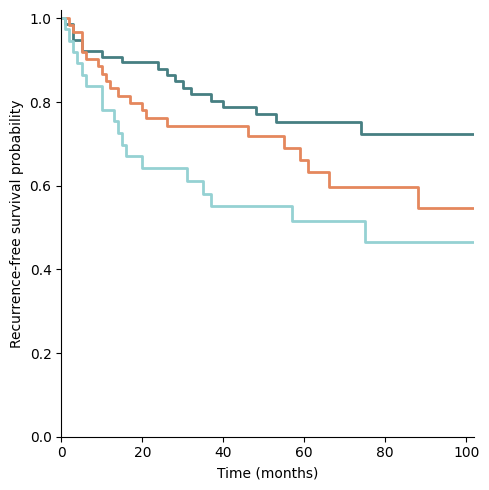

<lifelines.CoxPHFitter: fitted with 180 total observations, 118 right-censored observations>
             duration col = 'PFS'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 180
number of events observed = 62
   partial log-likelihood = -281.72
         time fit was run = 2026-04-09 04:29:08 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Cluster_S  0.82      2.28      0.32            0.19            1.46                1.21                4.31
Cluster_T  0.38      1.47      0.31           -0.21            0.98                0.81                2.67

           cmp to    z    p  -log2(p)
covariate                            
Cluster_S    0.00 2.54 0.01      6.49
Cluster_T    0.00 1.26 0.21      2.26
---
Concordance = 0.60
Partial AIC = 567.45
log-likelihood ratio test = 6.27 on 2 df
-log2(p) of ll-ratio test = 4.53


Hazard Ratios (vs Cluster 1):
                  HR  95% CI lower  95% CI upper
covariate                                      
Cluster_S  2.281111      1.206866      4.311557
Cluster_T  1.468797      0.806834      2.673864


In [11]:
# --- 1. Build patient-level dataframe ---
patient_df = (
    data.obs[[
        'Casenumber', 'Recurrence_overall', 'Recurrence_3yrs',
        'PFS', 'Time_to_recurrence', 'Time_to_death', 'Mortality'
    ]]
    .drop_duplicates('Casenumber')
    .merge(
        umap_patient[['Cluster']].reset_index().rename(columns={'index': 'Casenumber'}),
        on='Casenumber'
    )
)

# --- 2. Drop cluster 3, fix dtypes ---
patient_df = patient_df[patient_df['Cluster'] != 'G'].copy()
patient_df['Cluster'] = pd.Categorical(
    patient_df['Cluster'], 
    categories=['D', 'T', 'S'],  # explicitly exclude G
    ordered=False
)

# Use Recurrence_overall as the event (not Recurrence_3yrs)
patient_df['event'] = patient_df['Recurrence_overall'].fillna(0).astype(int)

# PFS = time to recurrence for events; for non-events, use time to death
# if the patient died (competing event), otherwise last follow-up
patient_df['PFS'] = pd.to_numeric(patient_df['PFS'], errors='coerce')
patient_df['Time_to_death'] = pd.to_numeric(patient_df['Time_to_death'], errors='coerce')

# For patients who died without recurrence, censor at time of death
died_no_recurrence = (patient_df['event'] == 0) & (patient_df['Mortality'] == 1)
patient_df.loc[died_no_recurrence, 'PFS'] = patient_df.loc[died_no_recurrence, 'Time_to_death']

patient_df = patient_df.dropna(subset=['PFS'])

print("Event counts per cluster:")
print(patient_df.groupby('Cluster')['event']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={'sum': 'n_recurred', 'count': 'n_total', 'mean': 'rate'}))

# --- 3. Kaplan-Meier curves ---
fig, ax = plt.subplots(figsize=(5, 5))

for cluster, grp in patient_df.groupby('Cluster'):
    color = CLUSTER_COLORS[cluster]
    kmf = KaplanMeierFitter()
    kmf.fit(
        grp['PFS'],
        grp['event'],                          # Recurrence_overall
        label=f'Cluster {cluster} (n={len(grp)})'
    )
    kmf.plot_survival_function(
        ax=ax,
        color=color,
        ci_show=False,                          # show CI — useful with small n
        ci_alpha=0.15,
        lw=2,
    )

# --- 4. Log-rank tests ---
# Overall
results = multivariate_logrank_test(
    patient_df['PFS'],
    patient_df['Cluster'],
    patient_df['event']
)

# Pairwise
clusters = patient_df['Cluster'].cat.categories.tolist()
pairwise_results = []
for c1, c2 in combinations(clusters, 2):
    g1 = patient_df[patient_df['Cluster'] == c1]
    g2 = patient_df[patient_df['Cluster'] == c2]
    lr = logrank_test(
        g1['PFS'], g2['PFS'],
        g1['event'], g2['event']
    )
    pairwise_results.append({'Cluster A': c1, 'Cluster B': c2, 'p-value': lr.p_value})

pairwise_df = pd.DataFrame(pairwise_results)
print("\nPairwise log-rank p-values:")
print(pairwise_df.to_string(index=False))
ax.set_xlabel('Time (months)')
ax.set_ylabel('Recurrence-free survival probability')
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 102)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "tmp", "kaplan_meier.pdf"), bbox_inches='tight')
plt.show()

# --- 5. Cox PH (Cluster 1 as reference) ---
patient_df['Cluster'] = pd.Categorical(
    patient_df['Cluster'], categories=['D', 'S', 'T'], ordered=False
)
cox_df = pd.get_dummies(
    patient_df[['PFS', 'event', 'Cluster']],
    columns=['Cluster'],
    drop_first=True
)
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='PFS', event_col='event')
cph.print_summary()

hr_df = pd.concat([
    np.exp(cph.params_).rename('HR'),
    np.exp(cph.confidence_intervals_).rename(columns={
        '95% lower-bound': '95% CI lower',
        '95% upper-bound': '95% CI upper'
    })
], axis=1)
print("\nHazard Ratios (vs Cluster 1):\n", hr_df)

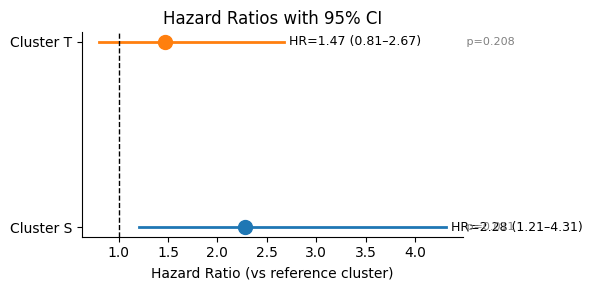

In [12]:
# --- 6. Forest plot of Hazard Ratios ---
fig, ax = plt.subplots(figsize=(6, 3))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
y_positions = range(len(hr_df))

for i, (idx, row) in enumerate(hr_df.iterrows()):
    ax.plot([row['95% CI lower'], row['95% CI upper']], [i, i], 
            color=colors[i], linewidth=2)
    ax.scatter(row['HR'], i, color=colors[i], s=100, zorder=5)
    ax.text(row['95% CI upper'] + 0.05, i, f"HR={row['HR']:.2f} ({row['95% CI lower']:.2f}–{row['95% CI upper']:.2f})",
            va='center', fontsize=9)

# reference line at HR=1
ax.axvline(x=1, color='black', linestyle='--', linewidth=1)

ax.set_yticks(list(y_positions))
ax.set_yticklabels([idx.replace('Cluster_', 'Cluster ') for idx in hr_df.index])
ax.set_xlabel('Hazard Ratio (vs reference cluster)')
ax.set_title('Hazard Ratios with 95% CI')

# add p-values from cox summary
pvals = cph.summary['p']
for i, (idx, pval) in enumerate(pvals.items()):
    ax.text(ax.get_xlim()[1], i, f' p={pval:.3f}', va='center', fontsize=8, color='grey')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "tmp", "hazard_ratios_forest_plot.pdf"), bbox_inches='tight')
plt.show()

In [ ]:
os.environ['OPENBLAS_NUM_THREADS'] = '10'
os.environ['OMP_NUM_THREADS'] = '10'

In [20]:
# --- 1. Get indices of B and T cells (no copy) ---
cell_mask = data.obs['Celltype'].isin(['Bcells', 'CD8Tcells', 'CD4Tcells'])
cell_idx = data.obs_names[cell_mask]

# --- 2. Subsample indices only ---
if len(cell_idx) > 100_000:
    rng = np.random.default_rng(42)
    cell_idx = rng.choice(cell_idx, size=50_000, replace=False)

# --- 3. Get marker indices and extract from layers ---
markers = ['CD3', 'CD8a', 'CD4', 'CD20', 'CD45RA', 'CD45RO', 'PD1', 'ICOS', 'FoxP3', 'GRZB']
marker_mask = data.var_names.isin(markers)

# extract only the slice we need from counts layer
marker_idx = [data.var_names.get_loc(m) for m in markers]
cell_int_idx = data.obs_names.get_indexer(cell_idx)

X = data.layers['corrected'][np.ix_(cell_int_idx, marker_idx)]

# convert to dense if sparse
if hasattr(X, 'toarray'):
    X = X.toarray()

# X = np.arcsinh(X)

# X_scaled = StandardScaler().fit_transform(X)
# reducer = umap.UMAP(n_neighbors=100, min_dist=0.1, metric='euclidean')
# X_umap = reducer.fit_transform(X_scaled)

from sklearn.manifold import TSNE

X_scaled = StandardScaler().fit_transform(X)
reducer = TSNE(n_components=2, perplexity=50, learning_rate='auto', 
               init='pca', random_state=42, n_jobs=-1)
X_tsne = reducer.fit_transform(X_scaled)

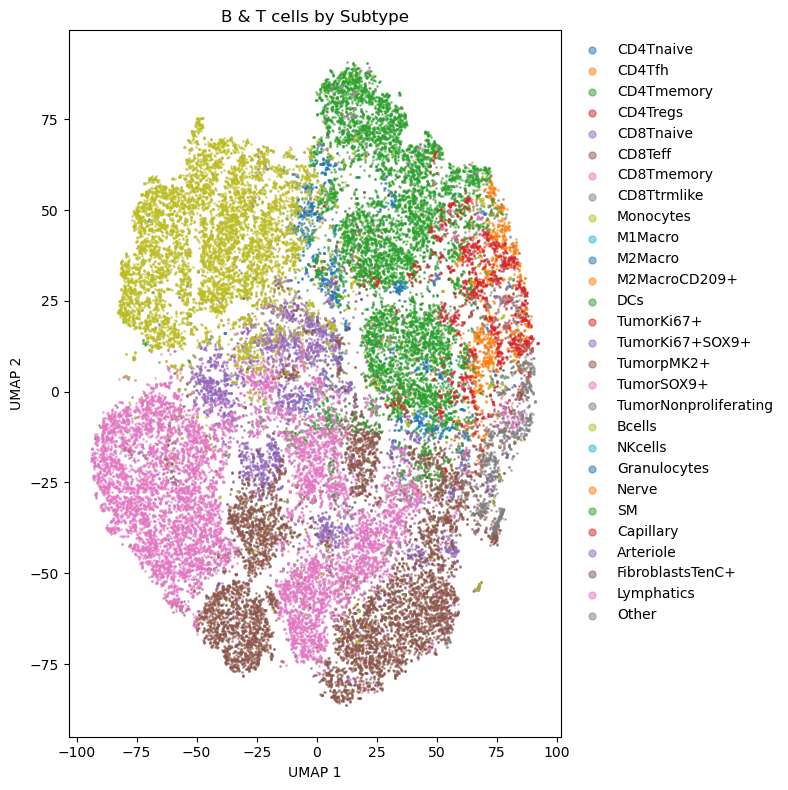

In [21]:
# get the metadata for your subsampled cells
obs_sub = data.obs.loc[cell_idx, ['Celltype', 'Subtype']].copy()

# plot
fig, ax = plt.subplots(figsize=(8, 8))
for subtype in obs_sub['Subtype'].cat.categories:
    mask = obs_sub['Subtype'] == subtype
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        s=1, label=subtype, alpha=0.5
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=5, bbox_to_anchor=(1.01, 1), frameon=False)
ax.set_title('B & T cells by Subtype')
plt.tight_layout()
plt.show()

# Figure 2c

In [18]:
from scipy.stats import wilcoxon
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# --- 0. Map cluster labels ---
casenumber_to_cluster = umap_patient['Cluster'].to_dict()
data.obs['Cluster'] = data.obs['Casenumber'].map(casenumber_to_cluster)

# --- 1. Filter zones ---
zone_mask = data.obs['Sector'].isin(['Tumorborder', 'Stromaborder'])
obs_filtered = data.obs[zone_mask].copy()

# --- 2. Cell type groupings ---
group_gaps = {
    'Tumor':    ['TumorNonproliferating', 'TumorKi67+', 'TumorKi67+SOX9+', 'TumorSOX9+', 'TumorpMK2+'],
    'CD8 T':    ['CD8Tnaive', 'CD8Tmemory', 'CD8Teff', 'CD8Ttrmlike'],
    'CD4 T':    ['CD4Tnaive', 'CD4Tmemory', 'CD4Tregs', 'CD4Tfh'],
    'Myeloid':  ['M1Macro', 'M2Macro', 'M2MacroCD209+', 'Monocytes', 'DCs', 'Granulocytes'],
    'Lymphoid': ['Bcells', 'NKcells'],
    'Stromal':  ['FibroblastsTenC+', 'SM', 'Nerve'],
    'Vascular': ['Arteriole', 'Capillary', 'Lymphatics'],
}
celltype_order = [ct for group in group_gaps.values() for ct in group]

# --- 3. Raw relative frequencies ---
freq = (
    obs_filtered
    .groupby(['Casenumber', 'Subtype'])
    .size()
    .unstack(fill_value=0)
)
freq = freq.div(freq.sum(axis=1), axis=0)
freq = freq.reindex(columns=[c for c in celltype_order if c in freq.columns], fill_value=0)

# --- 4. Scale to 1st–99th percentile ---
p1  = freq.quantile(0.00)
p99 = freq.quantile(1.00)
freq_scaled = freq.clip(lower=p1, upper=p99, axis=1)
freq_scaled = (freq_scaled - p1) / (p99 - p1).replace(0, 1)

# --- 5. Z-score per cell type across all patients (for color) ---
global_mean = freq_scaled.mean()
global_std  = freq_scaled.std().replace(0, 1)

# --- 6. Merge cluster labels ---
freq_scaled['Cluster'] = freq_scaled.index.map(casenumber_to_cluster)
freq_scaled = freq_scaled.dropna(subset=['Cluster'])

cluster_order = ['D', 'G', 'T', 'S']
clusters = [c for c in cluster_order if c in freq_scaled['Cluster'].unique()]
celltypes = [c for c in celltype_order if c in freq_scaled.columns]

# --- 7. Per cluster per cell type: median z-score and Wilcoxon vs global mean ---
wilcox_results = {}
median_zscore  = {}

for cluster in clusters:
    sub = freq_scaled[freq_scaled['Cluster'] == cluster]
    for ct in celltypes:
        vals = sub[ct].dropna().values
        # z-score of this cluster's median relative to global distribution
        z = (np.median(vals) - global_mean[ct]) / global_std[ct]
        median_zscore[(cluster, ct)] = z

        if len(vals) < 5:
            wilcox_results[(cluster, ct)] = 1.0
            continue
        centered = vals - global_mean[ct]
        try:
            _, p = wilcoxon(centered, zero_method='wilcox', alternative='two-sided')
        except ValueError:
            p = 1.0
        wilcox_results[(cluster, ct)] = p

# --- 8. Colormap: diverging, centered at 0 ---
all_z = list(median_zscore.values())
z_abs_max = np.percentile(np.abs(all_z), 95)  # robust color range
norm  = TwoSlopeNorm(vmin=-z_abs_max, vcenter=0, vmax=z_abs_max)
cmap  = cm.RdBu_r

# --- 9. X positions ---
x_positions = {}
x = 0
for group_name, members in group_gaps.items():
    for ct in members:
        if ct in celltypes:
            x_positions[ct] = x
            x += 1
    x += 0.8

color_ct_dict = {ct: COLOR_MAP.get(ct, '#AAAAAA') for ct in celltype_order}

# --- 11. Plot ---
fig, axes = plt.subplots(
    len(clusters) + 1, 1,
    figsize=(15, 1.2 * len(clusters) + 0.8),
    sharex=True,
    gridspec_kw={'height_ratios': [2.5] * len(clusters) + [0.3]}
)
ax_color_bar = axes[-1]
plot_axes    = axes[:-1]

for ax, cluster in zip(plot_axes, clusters):
    sub = freq_scaled[freq_scaled['Cluster'] == cluster]

    for ct in celltypes:
        if ct not in sub.columns:
            continue
        vals = sub[ct].dropna().values
        if len(vals) < 3:
            continue
        xpos = x_positions[ct]
        z    = median_zscore[(cluster, ct)]
        p    = wilcox_results[(cluster, ct)]
        color = cmap(norm(z))

        parts = ax.violinplot(vals, positions=[xpos], widths=0.7,
                              showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.85)
            if p < 0.05:
                pc.set_edgecolor('black')
                pc.set_linewidth(1.2)
            else:
                pc.set_edgecolor('none')
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.5)

    ax.set_ylabel(f'Cluster {cluster}', fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks([])

# --- 12. Bottom color bar (cell type families) ---
ax_color_bar.axis('off')
for ct in celltypes:
    xpos  = x_positions[ct]
    color = color_ct_dict.get(ct, '#AAAAAA')
    ax_color_bar.add_patch(
        plt.Rectangle((xpos - 0.4, 0.2), 0.4, 0.8,
                      color=color, clip_on=False,
                      transform=ax_color_bar.transData)
    )

for group_name, members in group_gaps.items():
    valid = [ct for ct in members if ct in x_positions]
    if not valid:
        continue
    x_mid = (x_positions[valid[0]] + x_positions[valid[-1]]) / 2
    ax_color_bar.text(x_mid, 0.2, group_name, ha='center', va='top',
                      fontsize=8)

ax_color_bar.set_xlim(plot_axes[0].get_xlim())
ax_color_bar.set_ylim(0, 1)


# --- 13. Colorbar for z-score ---
fig.subplots_adjust(right=0.88)  # make room on the right
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.4])  # [left, bottom, width, height]
norm = TwoSlopeNorm(vmin=-1.05, vcenter=0, vmax=1.05)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'])
cbar.set_label('z-score vs global mean', fontsize=8)
cbar.ax.tick_params(labelsize=7)


plt.suptitle('Cell type frequency by cluster\n(Tumorborder + Stromaborder)',
             fontsize=11, y=1.01)
plt.subplots_adjust(right=0.88, hspace=0.05) 
plt.savefig(os.path.join(base_dir, "tmp", "violin_cluster_celltype.pdf"), bbox_inches='tight')
plt.show()

# Figure 2d

In [19]:
cell_types = ['TumorNonproliferating', 'CD8Tmemory', 'Granulocytes', 'TumorSOX9+']
y_limits = {
    'TumorNonproliferating': (0, 1),
    'CD8Tmemory':            (0, 0.2),
    'Granulocytes':          (0, 1),
    'TumorSOX9+':            (0, 1),
}
bin_size = 20
smooth_window = 5

df_all = data.obs[data.obs['Distance_to_tumor'].between(-500, 500)].copy()
df_all['Distance_to_tumor'] = df_all['Distance_to_tumor'].astype(float)

bins = np.arange(-500, 501, bin_size)
bin_centers = bins[:-1] + bin_size / 2

cluster_order = ['D', 'G', 'T', 'S']
clusters = [c for c in cluster_order if c in freq_scaled['Cluster'].unique()]

fig, axes = plt.subplots(
    len(clusters), len(cell_types),
    figsize=(9, 1.2 * len(clusters) + 0.8),
    sharex=False, sharey=False  # manual per-column y limits
)

for row, cluster in enumerate(clusters):
    subset = df_all[df_all['Cluster'] == cluster].copy()
    all_counts, _ = np.histogram(subset['Distance_to_tumor'], bins=bins)

    for col, cell_type in enumerate(cell_types):
        ax = axes[row, col]

        ct_counts, _ = np.histogram(
            subset.loc[subset['Subtype'] == cell_type, 'Distance_to_tumor'], bins=bins
        )

        freq = np.where(all_counts > 0, ct_counts / all_counts, np.nan)
        freq_series = pd.Series(freq).rolling(window=smooth_window, center=True, min_periods=1).mean()

        color = COLOR_MAP.get(cell_type, '#AAAAAA')
        ax.plot(bin_centers, freq_series, color=color, linewidth=2.5)
        ax.fill_between(bin_centers, freq_series, alpha=0.2, color=color)
        ax.axvline(0, color='black', linestyle=':', linewidth=1)

        ax.set_xlim(-500, 500)
        ax.set_ylim(*y_limits[cell_type])

        # X ticks every 250
        ax.set_xticks([-500, -250, 0, 250, 500])

        # Remove y axis ticks and labels entirely
        ax.set_yticks([])
        ax.set_yticklabels([])

        # Column headers (top row only)
        if row == 0:
            ax.set_title(cell_type, fontsize=8, fontweight='bold')

        # Row labels (left column only)
        if col == 0:
            ax.set_ylabel(f'Cluster {cluster}', fontsize=8)

        # X axis label (bottom row only)
        if row == len(clusters) - 1:
            ax.set_xlabel('Distance (µm)', fontsize=7)
            ax.tick_params(axis='x', labelsize=6)
        else:
            ax.tick_params(axis='x', labelbottom=False, length=0)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "tmp", "celltype_frequency_by_cluster.pdf"), bbox_inches='tight', dpi=300)
plt.show()

In [20]:
records = []

for cluster in clusters:
    subset = df_all[df_all['Cluster'] == cluster].copy()
    all_counts, _ = np.histogram(subset['Distance_to_tumor'], bins=bins)

    for cell_type in cell_types:
        ct_counts, _ = np.histogram(
            subset.loc[subset['Subtype'] == cell_type, 'Distance_to_tumor'], bins=bins
        )
        freq = np.where(all_counts > 0, ct_counts / all_counts, np.nan)
        freq_series = pd.Series(freq).rolling(window=smooth_window, center=True, min_periods=1).mean()

        # Map bin_centers to freq_series values
        freq_by_position = dict(zip(bin_centers, freq_series))

        for x in range(-250, 251, 10):
            # Find nearest bin center
            nearest = min(bin_centers, key=lambda b: abs(b - x))
            records.append({
                'Cluster': cluster,
                'CellType': cell_type,
                'Distance': x,
                'Frequency': freq_by_position[nearest]
            })

freq_log = pd.DataFrame(records)
print(freq_log)

# Access example: CD8Tmemory in cluster T at distance 50µm into stroma
freq_log[(freq_log['Cluster'] == 'T') & 
         (freq_log['CellType'] == 'CD8Tmemory') & 
         (freq_log['Distance'] == 50)]

    Cluster               CellType  Distance  Frequency
0         D  TumorNonproliferating      -250   0.026921
1         D  TumorNonproliferating      -240   0.026921
2         D  TumorNonproliferating      -230   0.027616
3         D  TumorNonproliferating      -220   0.027616
4         D  TumorNonproliferating      -210   0.028434
..      ...                    ...       ...        ...
811       S             TumorSOX9+       210   0.585875
812       S             TumorSOX9+       220   0.585875
813       S             TumorSOX9+       230   0.602797
814       S             TumorSOX9+       240   0.602797
815       S             TumorSOX9+       250   0.593980

[816 rows x 4 columns]


,Cluster,CellType,Distance,Frequency
489,T,CD8Tmemory,50,0.059012


In [ ]:
freq_log

# Figure 3a

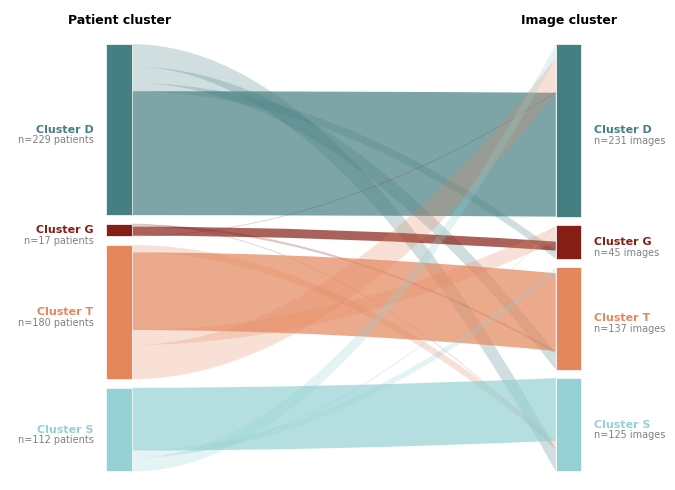

In [ ]:
# --- Build flow counts: patient cluster → image cluster ---
flow = (
    consistency
    .groupby(['PatientCluster', 'ImageCluster'])
    .size()
    .reset_index(name='Count')
)


cluster_order = ['S', 'T', 'G', 'D']
clusters = [c for c in cluster_order]
cluster_labels = {c: f'Cluster {c}' for c in clusters}

# Use your CLUSTER_COLORS
node_colors = {c: CLUSTER_COLORS[c] for c in clusters}

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')

n = len(clusters)
left_x  = 0.15
right_x = 0.85
bar_w   = 0.04

# Compute total images per patient cluster (left) and image cluster (right)
left_totals  = consistency.groupby('PatientCluster').size()
right_totals = consistency.groupby('ImageCluster').size()
total        = consistency.shape[0]

gap = 0.02
def get_bar_positions(totals, clusters, total):
    """Return (y_bottom, height) for each cluster bar, normalized to [0,1]."""
    positions = {}
    y = 0
    for c in clusters:
        h = totals.get(c, 0) / total * (1 - gap * (n - 1))
        positions[c] = (y, h)
        y += h + gap
    return positions

left_pos  = get_bar_positions(left_totals,  clusters, total)
right_pos = get_bar_positions(right_totals, clusters, total)

# Track current fill level for each bar (for stacking flows)
left_fill  = {c: left_pos[c][0]  for c in clusters}
right_fill = {c: right_pos[c][0] for c in clusters}

# Draw flows
for _, row in flow.sort_values(['PatientCluster', 'ImageCluster']).iterrows():
    pc, ic, count = row['PatientCluster'], row['ImageCluster'], row['Count']
    frac = count / total * (1 - gap * (n - 1))

    ly = left_fill[pc]
    ry = right_fill[ic]
    left_fill[pc]  += frac
    right_fill[ic] += frac

    # Bezier ribbon
    verts = [
        (left_x + bar_w, ly),
        (left_x + bar_w, ly + frac),
        ((left_x + right_x) / 2, ly + frac),
        (right_x, ry + frac),
        (right_x, ry),
        ((left_x + right_x) / 2, ly),
        (left_x + bar_w, ly),
    ]
    from matplotlib.path import Path
    codes = [Path.MOVETO, Path.LINETO, Path.CURVE3,
             Path.CURVE3, Path.LINETO, Path.CURVE3, Path.CURVE3]

    # Color by patient cluster, alpha by whether it's self-flow
    alpha = 0.7 if pc == ic else 0.25
    color = node_colors[pc]
    patch = mpatches.PathPatch(
        Path(verts, codes), facecolor=color, edgecolor='none', alpha=alpha
    )
    ax.add_patch(patch)

# Draw bars and labels
for c in clusters:
    # Left bars
    ly, lh = left_pos[c]
    ax.add_patch(plt.Rectangle(
        (left_x, ly), bar_w, lh,
        facecolor=node_colors[c], edgecolor='white', linewidth=0.5
    ))
    ax.text(left_x - 0.02, ly + lh / 2, cluster_labels[c],
            ha='right', va='center', fontsize=8, fontweight='bold',
            color=node_colors[c])
    ax.text(left_x - 0.02, ly + lh / 2 - 0.025,
            f'n={left_totals.get(c, 0)} patients',
            ha='right', va='center', fontsize=7,
            color='gray')

    # Right bars
    ry, rh = right_pos[c]
    ax.add_patch(plt.Rectangle(
        (right_x, ry), bar_w, rh,
        facecolor=node_colors[c], edgecolor='white', linewidth=0.5
    ))
    ax.text(right_x + bar_w + 0.02, ry + rh / 2, cluster_labels[c],
            ha='left', va='center', fontsize=8, fontweight='bold',
            color=node_colors[c])
    ax.text(right_x + bar_w + 0.02, ry + rh / 2 - 0.025,
            f'n={right_totals.get(c, 0)} images',
            ha='left', va='center', fontsize=7,
            color='gray')

ax.text(left_x + bar_w / 2, 1.04, 'Patient cluster',
        ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.text(right_x + bar_w / 2, 1.04, 'Image cluster',
        ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.08)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "tmp", 'sankey_patient_image_clusters.pdf'), bbox_inches='tight')
plt.show()

# Figure 3c

    Combo  Count
4     D/S     37
6     D/T     34
0       D     29
10      S     19
12      T     17
1     D/G     12
9     G/T     10
11    S/T      9
5   D/S/T      7
2   D/G/S      4
3   D/G/T      4
8     G/S      3
7       G      2


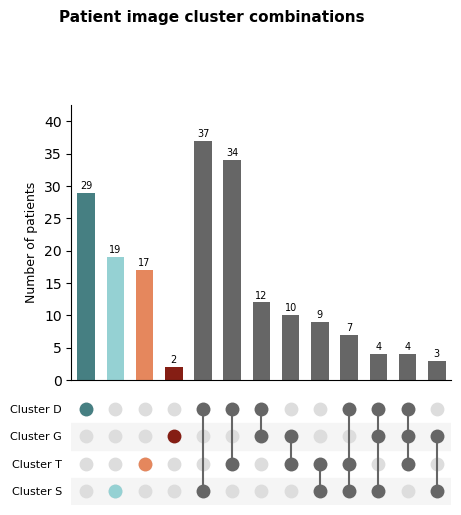

In [129]:
# --- Build global combo counts ignoring patient cluster ---
patient_combos_global = (
    consistency
    .reset_index(drop=True)
    .groupby('Casenumber')['ImageCluster']
    .apply(lambda x: '/'.join(str(c) for c in sorted(x.unique())))
    .rename('Combo')
    .reset_index()
)

combo_counts_global = (
    patient_combos_global
    .groupby('Combo')
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

print(combo_counts_global)

# Custom ordering: pure cases first (descending), then mixed (descending)
pure   = combo_counts_global[combo_counts_global['Combo'].apply(lambda x: '/' not in x)].sort_values('Count', ascending=False)
mixed  = combo_counts_global[combo_counts_global['Combo'].apply(lambda x: '/' in x)].sort_values('Count', ascending=False)
combo_counts_ordered = pd.concat([pure, mixed]).reset_index(drop=True)

combos     = combo_counts_ordered['Combo'].tolist()
counts     = combo_counts_ordered['Count'].tolist()
cluster_order_upset = ['D', 'G', 'T', 'S']  # your desired order for dot matrix

combo_sets = [c.split('/') for c in combos]  # remove int() cast

all_clusters = ['S', 'T', 'G', 'D']
n_combos     = len(combos)
n_clusters   = len(all_clusters)

fig = plt.figure(figsize=(5, 5))

bar_h = 0.55
dot_h = 0.22   # was 0.35 — smaller dot matrix
left  = 0.22
right = 0.98

bar_ax = fig.add_axes([left, dot_h + 0.05, right - left, bar_h])
dot_ax = fig.add_axes([left, 0.02,          right - left, dot_h])

bar_w     = 0.6
positions = np.arange(n_combos)

# --- Bar chart ---
for i, (combo, count, cset) in enumerate(zip(combos, counts, combo_sets)):
    color = CLUSTER_COLORS[cset[0]] if len(cset) == 1 else '#666666'
    bar_ax.bar(i, count, width=bar_w, color=color, edgecolor='none')
    bar_ax.text(i, count + 0.3, str(count), ha='center', va='bottom', fontsize=7)

bar_ax.set_xlim(-0.5, n_combos - 0.5)
bar_ax.set_xticks([])
bar_ax.set_ylabel('Number of patients', fontsize=9)
bar_ax.spines['top'].set_visible(False)
bar_ax.spines['right'].set_visible(False)
bar_ax.set_ylim(0, max(counts) * 1.15)

# --- Dot matrix ---
dot_ax.set_xlim(-0.5, n_combos - 0.5)
dot_ax.set_ylim(-0.5, n_clusters - 0.5)
dot_ax.set_yticks(range(n_clusters))
dot_ax.set_yticklabels([f'Cluster {c}' for c in all_clusters], fontsize=8)
dot_ax.set_xticks([])
dot_ax.tick_params(left=False)
dot_ax.spines['top'].set_visible(False)
dot_ax.spines['right'].set_visible(False)
dot_ax.spines['left'].set_visible(False)
dot_ax.spines['bottom'].set_visible(False)

# Background dots (inactive)
for i in range(n_combos):
    for j, c in enumerate(all_clusters):
        dot_ax.scatter(i, j, color='#DDDDDD', s=80, zorder=2)

# Active dots and connecting lines
for i, cset in enumerate(combo_sets):
    color = CLUSTER_COLORS[cset[0]] if len(cset) == 1 else '#666666'
    y_positions = [all_clusters.index(c) for c in cset]
    for yp in y_positions:
        dot_ax.scatter(i, yp, color=color, s=80, zorder=3)
    if len(cset) > 1:
        dot_ax.plot([i, i], [min(y_positions), max(y_positions)],
                    color=color, linewidth=1.5, zorder=2)

# Alternating row shading
for j in range(n_clusters):
    if j % 2 == 0:
        dot_ax.axhspan(j - 0.5, j + 0.5, color='#F5F5F5', zorder=0)

plt.suptitle('Patient image cluster combinations', fontsize=11, fontweight='bold', y=1.01)
plt.savefig(os.path.join(base_dir, 'tmp', 'upset_image_clusters.pdf'), bbox_inches='tight')
plt.show()



# Extract functional expression

In [13]:
# Define the markers of interest
functional_markers = ["Ki67", "SOX9", "pMK2", "pS6", "COX2", "HIFa", "NFkB", "STAT3", "CD36",
                      "GRZB", "NE", "MMP9", "MPO", "PDL1", "PD1", "Vista", "ICOS", "VEGF", "CD44", "HLADR"]

# Make sure all markers exist in your data
markers = [m for m in data.var_names]# m in functional_markers if m in data.var_names]

# Get the arcsinh-transformed counts (or raw counts if you prefer)
X = pd.DataFrame(np.arcsinh(np.sinh(data.layers['corrected']) + 1),
# X = pd.DataFrame(np.arcsinh(data.layers['counts']),
                 columns=data.var_names,
                 index=data.obs_names)

# Add obs information: Image, Subtype, Sector (you called it 'Sector', adjust if different)
X = X.join(data.obs[['Image', 'Subtype', 'Sector']])

# First, compute counts per group
counts = (
    X.groupby(["Image", "Subtype", "Sector"])
    .size()
)

# Select only groups with >10
valid_groups = counts[counts > 10].index

# Group by Image, Subtype, Sector and take median
median_df = X.groupby(['Image', 'Subtype', 'Sector'])[markers].mean().loc[valid_groups].reset_index()

# Melt the marker columns to long format
median_long = median_df.melt(
    id_vars=['Image', 'Subtype', 'Sector'],
    value_vars=functional_markers,
    var_name='Marker',
    value_name='Expression'
)

# Create combined feature name: Subtype_Marker_Sector
median_long['Feature'] = median_long['Subtype'].astype(str) + "_" + median_long['Sector'].astype(str) + "_" + median_long['Marker'].astype(str)

# Pivot so that Images are rows and Features are columns
median_wide = median_long.pivot_table(
    index='Image',
    columns='Feature',
    values='Expression'
)

print(median_wide.shape)

# Load relevance mask
relevance = pd.read_csv(os.path.join(base_dir, "metadata", 'marker_relevance.csv'), index_col='Subtype')

# Build set of valid Feature strings: Subtype_Sector_Marker
valid_features = set()
for subtype in relevance.index:
    for marker in relevance.columns:
        if relevance.loc[subtype, marker] == 1:
            for sector in median_wide.columns.str.extract(r'_(.+)_')[0].unique():
                valid_features.add(f"{subtype}_{sector}_{marker}")

# Filter median_wide
median_wide_filtered = median_wide[[c for c in median_wide.columns if c in valid_features]]
print(f"Features before: {median_wide.shape[1]}, after: {median_wide_filtered.shape[1]}")

(538, 1780)
Features before: 1780, after: 905


In [14]:
FEATURE_NA_THRESH = 0.25
from sklearn.metrics import roc_auc_score

# --- Add image-level cluster and outcome to median_wide_filtered ---
freq_wide_image_flat = freq_wide_image.copy()
freq_wide_image_flat.index = freq_wide_image_flat.index.get_level_values('Image')

image_cluster_map = umap_image['Cluster']
image_cluster_map.index = image_cluster_map.index.get_level_values('Image')

median_wide_filtered['ImageCluster'] = median_wide_filtered.index.map(image_cluster_map)
median_wide_filtered['Casenumber']   = median_wide_filtered.index.map(
    data.obs.groupby('Image')['Casenumber'].first()
)
median_wide_filtered['Outcome'] = median_wide_filtered['Casenumber'].map(
    data.obs.groupby('Casenumber')['Recurrence_3yrs'].first()
)

feature_cols = [c for c in median_wide_filtered.columns 
                if c not in ['ImageCluster', 'Casenumber', 'Outcome']]

print(f"Total features in median_wide_filtered: {len(feature_cols)}")
print(f"Total images: {len(median_wide_filtered)}")
print(f"ImageCluster distribution:\n{median_wide_filtered['ImageCluster'].value_counts()}\n")

# --- Run Mann-Whitney per cluster per feature ---
results = []

skip_counts = {c: {'freq_col_missing': 0, 'median_zero': 0, 'too_few': 0, 
                   'low_prevalence': 0, 'tested': 0}
               for c in sorted(median_wide_filtered['ImageCluster'].dropna().unique())}

for cluster in sorted(median_wide_filtered['ImageCluster'].dropna().unique()):
    subset = median_wide_filtered[median_wide_filtered['ImageCluster'] == cluster]
    recur    = subset[subset['Outcome'] == 1]
    no_recur = subset[subset['Outcome'] == 0]

    cluster_images = image_cluster_map[image_cluster_map == cluster].index

    for feat in feature_cols:
        a = recur[feat].dropna()
        b = no_recur[feat].dropna()

        if len(a) < 3 or len(b) < 3:
            skip_counts[cluster]['too_few'] += 1
            continue
            
        na_a = recur[feat].isna().mean()
        na_b = no_recur[feat].isna().mean()
        if na_a > FEATURE_NA_THRESH or na_b > FEATURE_NA_THRESH:
            skip_counts[cluster]['low_prevalence'] += 1
            continue

        base     = '_'.join(feat.split('_')[:-1])
        freq_col = f"{base}_freq"

        if freq_col in freq_wide_image_flat.columns:
            cluster_freq_median = freq_wide_image_flat.loc[
                freq_wide_image_flat.index.isin(cluster_images), freq_col
            ].median()
            if cluster_freq_median == 0:
                skip_counts[cluster]['median_zero'] += 1
                continue
        else:
            skip_counts[cluster]['freq_col_missing'] += 1

        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        auc = stat / (len(a) * len(b))
        auc = max(auc, 1 - auc)  # always > 0.5
        skip_counts[cluster]['tested'] += 1
        results.append({
            'Cluster':        cluster,
            'Feature':        feat,
            'p_value':        p,
            'AUC':            auc,  
            'median_recur':   a.median(),
            'median_norecur': b.median(),
            'delta_median':   a.median() - b.median(),
            'n_recur':        len(a),
            'n_norecur':      len(b),
        })

# --- Per-cluster skip summary ---
print("=== Per-cluster filtering summary ===")
for cluster, counts in skip_counts.items():
    total = len(feature_cols)
    print(f"\nCluster {cluster} (total features: {total}):")
    print(f"  Skipped — too few observations:  {counts['too_few']}")
    print(f"  Skipped — median freq == 0:       {counts['median_zero']}")
    print(f"  Skipped — freq col not found:     {counts['freq_col_missing']}")
    print(f"  Tested:                           {counts['tested']}")
    print(f"  Skipped — low prevalence (<75%):  {counts['low_prevalence']}")

    print(f"  Accounted for: {counts['too_few'] + counts['median_zero'] + counts['freq_col_missing'] + counts['low_prevalence'] + counts['tested']} / {total}")

results_df = pd.DataFrame(results).sort_values(['Cluster', 'p_value'])

results_df['fold_change'] = (
    (results_df['median_recur'] + 0.01) /
    (results_df['median_norecur'] + 0.01)
)
results_df['log2_fold_change'] = np.log2(results_df['fold_change'])
results_df['volcano_score'] = (
    -np.log10(results_df['p_value'] + 1e-10) *
    np.abs(results_df['log2_fold_change'])
)

print(f"\nTotal tests after median filter: {len(results_df)}")
for cluster in sorted(results_df['Cluster'].unique()):
    sig = results_df[(results_df['Cluster'] == cluster) & (results_df['p_value'] < 0.05)]
    print(f"Cluster {cluster}: {len(results_df[results_df['Cluster']==cluster])} tested, {len(sig)} significant (p<0.05)")

Total features in median_wide_filtered: 905
Total images: 538
ImageCluster distribution:
ImageCluster
D    231
T    137
S    125
G     45
Name: count, dtype: int64

=== Per-cluster filtering summary ===

Cluster D (total features: 905):
  Skipped — too few observations:  69
  Skipped — median freq == 0:       0
  Skipped — freq col not found:     0
  Tested:                           404
  Skipped — low prevalence (<75%):  432
  Accounted for: 905 / 905

Cluster G (total features: 905):
  Skipped — too few observations:  161
  Skipped — median freq == 0:       0
  Skipped — freq col not found:     0
  Tested:                           353
  Skipped — low prevalence (<75%):  391
  Accounted for: 905 / 905

Cluster S (total features: 905):
  Skipped — too few observations:  107
  Skipped — median freq == 0:       0
  Skipped — freq col not found:     0
  Tested:                           356
  Skipped — low prevalence (<75%):  442
  Accounted for: 905 / 905

Cluster T (total features: 90

In [104]:
# Determine optimal threshold for betweenness
clusters_to_plot = sorted(median_wide_filtered['ImageCluster'].dropna().unique())
target_density = 0.1  # aim for 10% of possible edges
thresholds = np.arange(0.3, 0.31, 0.05)

def get_protein(feature):
    return feature.split('_')[-1]

def build_graph(subset, corr_df, threshold):
    G = nx.Graph()
    G.add_nodes_from(subset.columns)
    for i, f1 in enumerate(subset.columns):
        for j, f2 in enumerate(subset.columns):
            if j <= i:
                continue

            if get_protein(f1) == get_protein(f2):
                continue
            r = corr_df.loc[f1, f2]
            if abs(r) >= threshold:
                G.add_edge(f1, f2, weight=abs(r))
    G.remove_nodes_from(list(nx.isolates(G)))
    return G

# Scan thresholds per cluster and pick the one closest to target density
optimal_thresholds = {}

for cluster in clusters_to_plot:
    sig_features = results_df[
        (results_df['Cluster'] == cluster) &
        (results_df['p_value'] < 0.05)
    ]['Feature'].tolist()
    sig_features = [f for f in sig_features if f in feature_cols]

    if len(sig_features) < 3:
        optimal_thresholds[cluster] = 0.5
        continue

    subset = median_wide_filtered[
        median_wide_filtered['ImageCluster'] == cluster
    ][sig_features].dropna(axis=1, how='all')
    subset = subset.apply(lambda col: col.fillna(col.median()))
    subset = subset.loc[:, subset.std() > 0]

    corr_arr, _ = spearmanr(subset, nan_policy='omit')
    if subset.shape[1] == 2:
        corr_arr = np.array([[1, corr_arr], [corr_arr, 1]])
    corr_df = pd.DataFrame(corr_arr, index=subset.columns, columns=subset.columns)

    best_thresh = thresholds[0]
    best_diff = np.inf

    for t in thresholds:
        G = build_graph(subset, corr_df, t)
        if len(G.nodes) < 2:
            continue
        d = nx.density(G)
        diff = abs(d - target_density)
        print(f"  Cluster {cluster}, threshold={t:.2f}, density={d:.3f}, nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
        if diff < best_diff:
            best_diff = diff
            best_thresh = t

    optimal_thresholds[cluster] = best_thresh
    print(f"  → Cluster {cluster} optimal threshold: {best_thresh:.2f}\n")

  Cluster D, threshold=0.30, density=0.161, nodes=105, edges=880
  → Cluster D optimal threshold: 0.30

  Cluster G, threshold=0.30, density=0.187, nodes=34, edges=105
  → Cluster G optimal threshold: 0.30

  Cluster S, threshold=0.30, density=0.198, nodes=14, edges=18
  → Cluster S optimal threshold: 0.30

  Cluster T, threshold=0.30, density=0.120, nodes=52, edges=159
  → Cluster T optimal threshold: 0.30



In [ ]:
# Volcano plot with betweenness
clusters_to_plot = sorted(median_wide_filtered['ImageCluster'].dropna().unique())
top_n_betweenness = 10
betweenness_all = {}  # cluster -> {feature: betweenness}
#corr_threshold = 0.5

for cluster in clusters_to_plot:
    sig_features = results_df[
        (results_df['Cluster'] == cluster) &
        (results_df['p_value'] < 0.05)
    ]['Feature'].tolist()
    sig_features = [f for f in sig_features if f in feature_cols]

    if len(sig_features) < 3:
        betweenness_all[cluster] = {}
        continue

    subset = median_wide_filtered[
        median_wide_filtered['ImageCluster'] == cluster
    ][sig_features].dropna(axis=1, how='all')
    subset = subset.apply(lambda col: col.fillna(col.median()))
    subset = subset.loc[:, subset.std() > 0]

    corr_arr, _ = spearmanr(subset, nan_policy='omit')
    if subset.shape[1] == 2:
        corr_arr = np.array([[1, corr_arr], [corr_arr, 1]])
    corr_df = pd.DataFrame(corr_arr, index=subset.columns, columns=subset.columns)

    def get_protein(feature):
        return feature.split('_')[-1]  # last element = protein
    
    corr_threshold = optimal_thresholds[cluster] 

    G = nx.Graph()
    G.add_nodes_from(subset.columns)
    for i, f1 in enumerate(subset.columns):
        for j, f2 in enumerate(subset.columns):
            if j <= i:
                continue
            # Skip if same protein
            if get_protein(f1) == get_protein(f2):
                continue
            r = corr_df.loc[f1, f2]
            if abs(r) >= corr_threshold:
                G.add_edge(f1, f2, weight=abs(r))

    G.remove_nodes_from(list(nx.isolates(G)))
    #betweenness_all[cluster] = nx.betweenness_centrality(G, weight='weight')
    #betweenness_all[cluster] = dict(G.degree(weight='weight'))
    betweenness_all[cluster] = nx.pagerank(G, weight='weight', alpha=0.9)

fig, axes = plt.subplots(1, len(clusters_to_plot),
                         figsize=(4 * len(clusters_to_plot), 4),
                         sharey=True)

legend_lines = {c: [] for c in clusters_to_plot}

# --- Compute global bmax across all clusters ---
global_bmax = max(
    max(betweenness_all[c].values()) if betweenness_all[c] else 0
    for c in clusters_to_plot
)


for ax, cluster in zip(axes, clusters_to_plot):
    color   = CLUSTER_COLORS[(cluster)]
    df_plot = results_df[results_df['Cluster'] == cluster].copy()
    df_plot['neglog10p']   = -np.log10(df_plot['p_value'] + 1e-10)
    df_plot['betweenness'] = df_plot['Feature'].map(
        betweenness_all.get(cluster, {})
    ).fillna(0)

    #bmax = df_plot['betweenness'].max()
    df_plot['size'] = 10 + (df_plot['betweenness'] / global_bmax * 400 if global_bmax > 0 else 10)

    sig  = df_plot['p_value'] < 0.05
    up   = df_plot['delta_median'] > 0
    down = df_plot['delta_median'] < 0

    ax.scatter(df_plot.loc[~sig, 'delta_median'],
               df_plot.loc[~sig, 'neglog10p'],
               s=df_plot.loc[~sig, 'size'],
               color='#CCCCCC', edgecolors='none', alpha=0.6, zorder=2)
    ax.scatter(df_plot.loc[sig & up, 'delta_median'],
               df_plot.loc[sig & up, 'neglog10p'],
               s=df_plot.loc[sig & up, 'size'],
               color=color, edgecolors='black', linewidths=0.3, alpha=0.8, zorder=3)
    ax.scatter(df_plot.loc[sig & down, 'delta_median'],
               df_plot.loc[sig & down, 'neglog10p'],
               s=df_plot.loc[sig & down, 'size'],
               color=color, edgecolors='black', linewidths=0.3,  alpha=0.8, zorder=3)

    ax.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)

    # --- Number top betweenness nodes ---
    top_nodes = sorted(
        [(f, b) for f, b in betweenness_all.get(cluster, {}).items() if b > 0],
        key=lambda x: x[1], reverse=True
    )[:top_n_betweenness]

    texts = []
    rank  = 1
    legend_lines[cluster] = []

    for feat, bw in top_nodes:
        row = df_plot[df_plot['Feature'] == feat]
        is_sig = not row.empty and row['p_value'].values[0] < 0.05

        if not is_sig:
            legend_lines[cluster].append((feat, bw, False))  # was: string
            rank += 1
            continue

        x = row['delta_median'].values[0]
        y = row['neglog10p'].values[0]

        texts.append(ax.text(x, y, str(rank),
                            fontsize=7, fontweight='bold',
                            ha='center', va='center', zorder=5))
        legend_lines[cluster].append((feat, bw, True))  # was: string
        rank += 1

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle='-', color='black', linewidth=0.6),
        expand_points=(1.5, 1.5),
        expand_text=(1.2, 1.2),
        force_points=(0.3, 0.3),
    )

    ax.set_xlabel('Δ median (recurrence − no recurrence)', fontsize=8)
    ax.set_title(f'Cluster {cluster}', fontsize=9, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_xlim(-1, 1)

axes[0].set_ylim(0, 4.5)
axes[0].set_ylabel('-log10(p)', fontsize=8)

# --- Size legend in first volcano panel ---
ax_leg = axes[-1]
bw_legend_vals  = [0.0, global_bmax * 0.5, global_bmax]
size_legend_vals = [10 + v / global_bmax * 200 for v in bw_legend_vals]
labels = [f'{v:.3f}' for v in bw_legend_vals]

for bv, sv, lb in zip(bw_legend_vals, size_legend_vals, labels):
    ax_leg.scatter([], [], s=sv, color='gray', edgecolors='black',
                   linewidths=0.3, alpha=0.6, label=lb)
ax_leg.legend(title='Betweenness', fontsize=6, title_fontsize=7,
              frameon=False, loc='upper left',
              handletextpad=0.5, labelspacing=0.8)


plt.suptitle('Functional features — volcano plots per cluster\n'
             '(size = betweenness centrality)',
             fontsize=10, fontweight='bold')
plt.tight_layout()

print("\nTop features by betweenness centrality:")
for cluster in clusters_to_plot:
    print(f"\nCluster {cluster}:")
    for feat, bw, is_sig in legend_lines[cluster]:
        sig_str = "" if is_sig else " (not significant)"
        print(f"  {feat} — {bw:.3f}{sig_str}")

plt.savefig(os.path.join(base_dir, 'tmp', 'volcano_betweenness_per_cluster.pdf'), bbox_inches='tight')
plt.show()


Top features by AUC:

Cluster D:
  CD8Tmemory_Stromaborder_pMK2 — AUC=0.701
  CD4Tregs_Stromacore_HLADR — AUC=0.693
  TumorNonproliferating_Tumorcore_HIFa — AUC=0.691
  M1Macro_Tumorborder_pMK2 — AUC=0.680
  CD4Tmemory_Tumorborder_pMK2 — AUC=0.677
  TumorNonproliferating_Tumorborder_HIFa — AUC=0.671
  M1Macro_Tumorborder_pS6 — AUC=0.668
  CD8Tmemory_Tumorborder_CD44 — AUC=0.664
  TumorKi67+_Tumorcore_HIFa — AUC=0.663
  TumorNonproliferating_Stromaborder_pMK2 — AUC=0.661

Cluster G:
  TumorNonproliferating_Tumorcore_pMK2 — AUC=0.777
  CD4Tmemory_Stromaborder_PD1 — AUC=0.775
  TumorKi67+_Tumorborder_pMK2 — AUC=0.760
  CD4Tmemory_Stromacore_PD1 — AUC=0.733
  CD8Tmemory_Stromacore_PD1 — AUC=0.731
  TumorNonproliferating_Tumorborder_pMK2 — AUC=0.727
  TumorKi67+SOX9+_Tumorborder_pMK2 — AUC=0.722
  TumorSOX9+_Tumorcore_pMK2 — AUC=0.720
  TumorSOX9+_Tumorborder_pMK2 — AUC=0.714
  M1Macro_Stromacore_PDL1 — AUC=0.709

Cluster T:
  Granulocytes_Tumorborder_MPO — AUC=0.742
  CD4Tfh_Stromaborder_

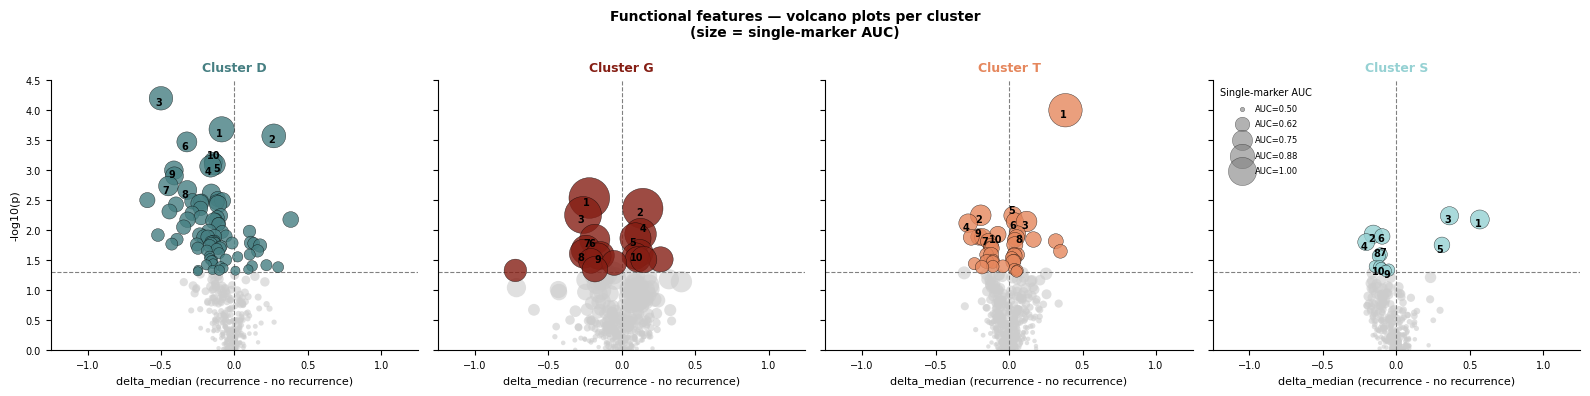

In [15]:
# Volcano plot
clusters_to_plot = ['D', 'G', 'T', 'S']
top_n_volcano = 10

fig, axes = plt.subplots(1, len(clusters_to_plot),
                         figsize=(4 * len(clusters_to_plot), 4),
                         sharey=True)

legend_lines = {c: [] for c in clusters_to_plot}

for ax, cluster in zip(axes, clusters_to_plot):
    color   = CLUSTER_COLORS[cluster]
    df_plot = results_df[results_df['Cluster'] == cluster].copy()
    df_plot['neglog10p'] = -np.log10(df_plot['p_value'] + 1e-10)
    df_plot['size'] = 10 + ((df_plot['AUC'] - 0.5) / 0.5) ** 3 * 5000

    sig  = df_plot['p_value'] < 0.05
    up   = df_plot['delta_median'] > 0
    down = df_plot['delta_median'] < 0

    ax.scatter(df_plot.loc[~sig, 'delta_median'],
               df_plot.loc[~sig, 'neglog10p'],
               s=df_plot.loc[~sig, 'size'],
               color='#CCCCCC', edgecolors='none', alpha=0.6, zorder=2)
    ax.scatter(df_plot.loc[sig & up, 'delta_median'],
               df_plot.loc[sig & up, 'neglog10p'],
               s=df_plot.loc[sig & up, 'size'],
               color=color, edgecolors='black', linewidths=0.3, alpha=0.8, zorder=3)
    ax.scatter(df_plot.loc[sig & down, 'delta_median'],
               df_plot.loc[sig & down, 'neglog10p'],
               s=df_plot.loc[sig & down, 'size'],
               color=color, edgecolors='black', linewidths=0.3, alpha=0.8, zorder=3)

    ax.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)

    # --- Label top N by AUC (significant only) ---
    top_nodes = (
        df_plot[sig]
        .nlargest(top_n_volcano, 'AUC')
        [['Feature', 'AUC']]
        .values.tolist()
    )

    texts = []
    rank  = 1
    legend_lines[cluster] = []

    for feat, auc_val in top_nodes:
        row = df_plot[df_plot['Feature'] == feat]
        if row.empty:
            continue

        x = row['delta_median'].values[0]
        y = row['neglog10p'].values[0]

        texts.append(ax.text(x, y, str(rank),
                             fontsize=7, fontweight='bold',
                             ha='center', va='center', zorder=5))
        legend_lines[cluster].append((feat, auc_val))
        rank += 1

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle='-', color='black', linewidth=0.6))

    ax.set_xlabel('delta_median (recurrence - no recurrence)', fontsize=8)
    ax.set_title(f'Cluster {cluster}', fontsize=9, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_xlim(-1.25, 1.25)

axes[0].set_ylim(0, 4.5)
axes[0].set_ylabel('-log10(p)', fontsize=8)

# --- Size legend ---
ax_leg = axes[-1]
auc_legend_vals  = [0.5, 0.625, 0.75, 0.875, 1.0]
size_legend_vals = [10 + ((v - 0.5) / 0.5) * 400 for v in auc_legend_vals]

for auc_val, sz in zip(auc_legend_vals, size_legend_vals):
    ax_leg.scatter([], [], s=sz, color='gray', edgecolors='black',
                   linewidths=0.3, alpha=0.6, label=f'AUC={auc_val:.2f}')
ax_leg.legend(title='Single-marker AUC', fontsize=6, title_fontsize=7,
              frameon=False, loc='upper left',
              handletextpad=0.5, labelspacing=0.8)

plt.suptitle('Functional features — volcano plots per cluster\n'
             '(size = single-marker AUC)',
             fontsize=10, fontweight='bold')
plt.tight_layout()

# --- Print legend ---
print("\nTop features by AUC:")
for cluster in clusters_to_plot:
    print(f"\nCluster {cluster}:")
    for feat, auc_val in legend_lines[cluster]:
        print(f"  {feat} — AUC={auc_val:.3f}")

plt.savefig(os.path.join(base_dir, 'tmp', 'volcano_score_per_cluster.pdf'), bbox_inches='tight')
plt.show()

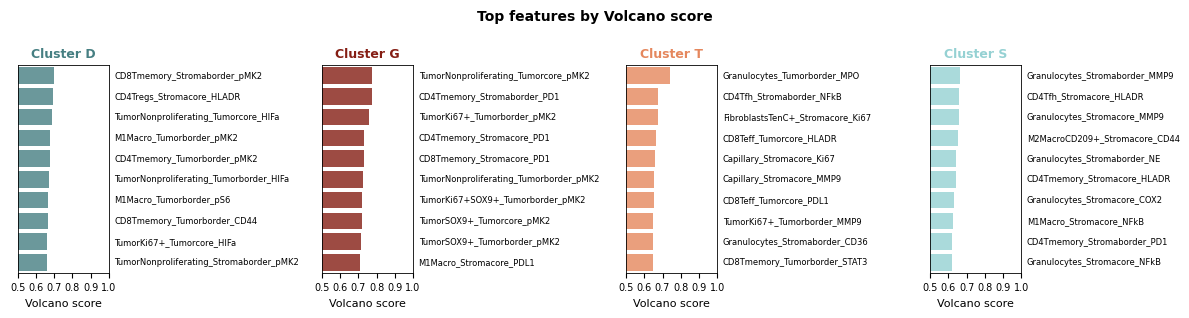

In [16]:
# Barplot
n_slots = 10
n_clusters=4

fig, axes = plt.subplots(1, n_clusters,
                         figsize=(3 * n_clusters, 3.2),
                         sharey=False, sharex=True)

for ax, cluster in zip(axes, clusters_to_plot):
    color   = CLUSTER_COLORS[(cluster)]
    entries = [(f, bw) for f, bw in legend_lines[cluster]]

    feats = [e[0] for e in entries] + [''] * (n_slots - len(entries))
    bws   = [e[1] for e in entries] + [0.0]  * (n_slots - len(entries))

    y_pos = list(range(n_slots - 1, -1, -1))

    for y, feat, bw in zip(y_pos, feats, bws):
        if feat:
            ax.barh(y, bw, height=0.8, color=color, edgecolor='none', alpha=0.8)

    # Box around plot area
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.6)
        ax.spines[spine].set_color("#000000")

    #ax.set_xlim(0, 0.16)
    ax.set_ylim(-0.5, n_slots - 0.5)
    ax.set_xlim(0.5, 1)
    ax.set_xticks(np.arange(0.5, 1.01, 0.1))
    ax.set_yticks([])
    ax.set_xlabel('Volcano score', fontsize=8)
    ax.set_title(f'Cluster {cluster}', fontsize=9, fontweight='bold', color=color)
    ax.tick_params(labelsize=7)

    # Labels to the right of the entire plot, aligned per row
    for y, feat in zip(y_pos, feats):
        if feat:
            ax.annotate(feat,
                        xy=(1, y),
                        xycoords=('axes fraction', 'data'),
                        xytext=(4, 0),
                        textcoords='offset points',
                        ha='left', va='center', fontsize=6,
                        annotation_clip=False)

plt.suptitle('Top features by Volcano score', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'tmp', 'volcanoscore_barplots_per_cluster.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()


Top features by volcano score:

Cluster D:
  TumorNonproliferating_Tumorcore_HIFa — score=1.729
  CD4Tregs_Stromacore_HLADR — score=1.538
  TumorKi67+_Tumorcore_HIFa — score=1.502
  TumorNonproliferating_Tumorborder_HIFa — score=1.480
  TumorNonproliferating_Stromaborder_pMK2 — score=1.454
  TumorNonproliferating_Stromaborder_HIFa — score=1.233
  M1Macro_Tumorborder_pMK2 — score=1.225
  CD8Tmemory_Stromaborder_pMK2 — score=1.185
  Bcells_Stromaborder_pMK2 — score=1.160
  CD4Tmemory_Tumorborder_pMK2 — score=1.148

Cluster G:
  CD4Tmemory_Stromaborder_PD1 — score=1.572
  TumorNonproliferating_Tumorcore_pMK2 — score=1.331
  CD4Tmemory_Stromacore_PD1 — score=1.170
  TumorKi67+_Tumorborder_pMK2 — score=1.169
  CD8Tmemory_Stromacore_PD1 — score=1.078
  CD8Tnaive_Stromacore_PD1 — score=0.980
  TumorNonproliferating_Tumorborder_pMK2 — score=0.963
  FibroblastsTenC+_Stromacore_pMK2 — score=0.800
  TumorSOX9+_Tumorcore_pMK2 — score=0.703
  TumorKi67+SOX9+_Tumorborder_pMK2 — score=0.680

Cluster

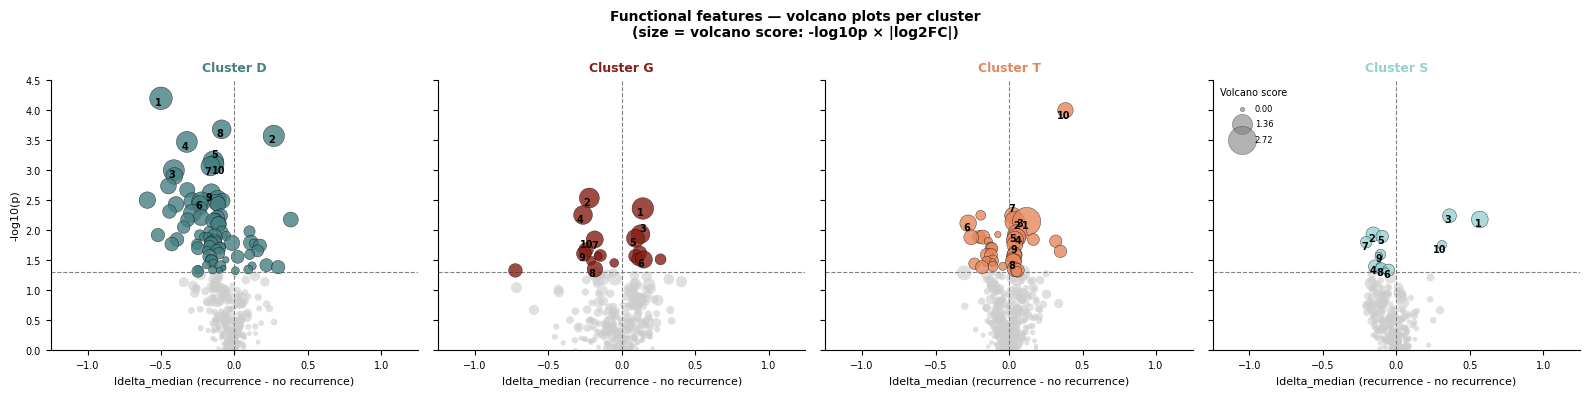

In [235]:
# Volcano plot
clusters_to_plot = ['D', 'G', 'T', 'S']
top_n_volcano = 10

fig, axes = plt.subplots(1, len(clusters_to_plot),
                         figsize=(4 * len(clusters_to_plot), 4),
                         sharey=True)

legend_lines = {c: [] for c in clusters_to_plot}

# --- Compute global score max for normalization ---
global_smax = results_df['volcano_score'].max()

for ax, cluster in zip(axes, clusters_to_plot):
    color   = CLUSTER_COLORS[cluster]
    df_plot = results_df[results_df['Cluster'] == cluster].copy()
    df_plot['neglog10p'] = -np.log10(df_plot['p_value'] + 1e-10)

    df_plot['size'] = 10 + (df_plot['volcano_score'] / global_smax * 400 if global_smax > 0 else 10)

    sig  = df_plot['p_value'] < 0.05
    up   = df_plot['delta_median'] > 0
    down = df_plot['delta_median'] < 0

    ax.scatter(df_plot.loc[~sig, 'delta_median'],
               df_plot.loc[~sig, 'neglog10p'],
               s=df_plot.loc[~sig, 'size'],
               color='#CCCCCC', edgecolors='none', alpha=0.6, zorder=2)
    ax.scatter(df_plot.loc[sig & up, 'delta_median'],
               df_plot.loc[sig & up, 'neglog10p'],
               s=df_plot.loc[sig & up, 'size'],
               color=color, edgecolors='black', linewidths=0.3, alpha=0.8, zorder=3)
    ax.scatter(df_plot.loc[sig & down, 'delta_median'],
               df_plot.loc[sig & down, 'neglog10p'],
               s=df_plot.loc[sig & down, 'size'],
               color=color, edgecolors='black', linewidths=0.3, alpha=0.8, zorder=3)

    ax.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)

    # --- Label top N by volcano score (significant only) ---
    top_nodes = (
        df_plot[sig]
        .nlargest(top_n_volcano, 'volcano_score')
        [['Feature', 'volcano_score']]
        .values.tolist()
    )

    texts = []
    rank  = 1
    legend_lines[cluster] = []

    for feat, score in top_nodes:
        row = df_plot[df_plot['Feature'] == feat]
        if row.empty:
            continue

        x = row['delta_median'].values[0]
        y = row['neglog10p'].values[0]

        texts.append(ax.text(x, y, str(rank),
                             fontsize=7, fontweight='bold',
                             ha='center', va='center', zorder=5))
        legend_lines[cluster].append((feat, score, True))
        rank += 1

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle='-', color='black', linewidth=0.6))

    ax.set_xlabel('ldelta_median (recurrence - no recurrence)', fontsize=8)
    ax.set_title(f'Cluster {cluster}', fontsize=9, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_xlim(-1.25, 1.25)

axes[0].set_ylim(0, 4.5)
axes[0].set_ylabel('-log10(p)', fontsize=8)

# --- Size legend ---
ax_leg = axes[-1]
score_legend_vals  = [0.0, global_smax * 0.5, global_smax]
size_legend_vals   = [10 + v / global_smax * 400 for v in score_legend_vals]
labels             = [f'{v:.2f}' for v in score_legend_vals]

for sv, sz, lb in zip(score_legend_vals, size_legend_vals, labels):
    ax_leg.scatter([], [], s=sz, color='gray', edgecolors='black',
                   linewidths=0.3, alpha=0.6, label=lb)
ax_leg.legend(title='Volcano score', fontsize=6, title_fontsize=7,
              frameon=False, loc='upper left',
              handletextpad=0.5, labelspacing=0.8)

plt.suptitle('Functional features — volcano plots per cluster\n'
             '(size = volcano score: -log10p × |log2FC|)',
             fontsize=10, fontweight='bold')
plt.tight_layout()

# --- Print legend ---
print("\nTop features by volcano score:")
for cluster in clusters_to_plot:
    print(f"\nCluster {cluster}:")
    for feat, score, is_sig in legend_lines[cluster]:
        print(f"  {feat} — score={score:.3f}")

plt.savefig(os.path.join(base_dir, 'tmp', 'volcano_score_per_cluster.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# Barplot
n_slots = 10
n_clusters=4

fig, axes = plt.subplots(1, n_clusters,
                         figsize=(3 * n_clusters, 3.2),
                         sharey=False, sharex=True)

for ax, cluster in zip(axes, clusters_to_plot):
    color   = CLUSTER_COLORS[(cluster)]
    entries = [(f, bw) for f, bw, is_sig in legend_lines[cluster] if is_sig]

    feats = [e[0] for e in entries] + [''] * (n_slots - len(entries))
    bws   = [e[1] for e in entries] + [0.0]  * (n_slots - len(entries))

    y_pos = list(range(n_slots - 1, -1, -1))

    for y, feat, bw in zip(y_pos, feats, bws):
        if feat:
            ax.barh(y, bw, height=0.8, color=color, edgecolor='none', alpha=0.8)

    # Box around plot area
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.6)
        ax.spines[spine].set_color("#000000")

    #ax.set_xlim(0, 0.16)
    ax.set_ylim(-0.5, n_slots - 0.5)
    ax.set_yticks([])
    ax.set_xlabel('Volcano score', fontsize=8)
    ax.set_title(f'Cluster {cluster}', fontsize=9, fontweight='bold', color=color)
    ax.tick_params(labelsize=7)

    # Labels to the right of the entire plot, aligned per row
    for y, feat in zip(y_pos, feats):
        if feat:
            ax.annotate(feat,
                        xy=(1, y),
                        xycoords=('axes fraction', 'data'),
                        xytext=(4, 0),
                        textcoords='offset points',
                        ha='left', va='center', fontsize=6,
                        annotation_clip=False)

plt.suptitle('Top features by Volcano score', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'tmp', 'volcanoscore_barplots_per_cluster.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

84
32


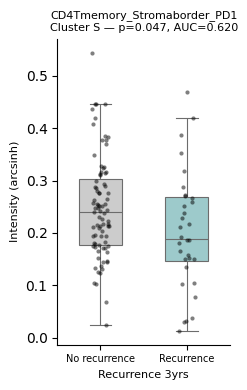

In [282]:
feature = "TumorNonproliferating_Tumorcore_HIFa"
cluster = 'D'

feature = "TumorNonproliferating_Tumorcore_pS6"
cluster = 'G'

feature = "Granulocytes_Tumorborder_MPO"
cluster = 'T'

feature = "Granulocytes_Stromaborder_MMP9"
cluster = 'S'

feature = "CD4Tmemory_Stromaborder_PD1"
cluster = 'S'

df_plot = median_wide_filtered[
    median_wide_filtered['ImageCluster'] == cluster
][[feature, 'Outcome']].dropna()

df_plot['Outcome'] = df_plot['Outcome'].astype(int)

fig, ax = plt.subplots(figsize=(2.5, 4))

sns.boxplot(data=df_plot, x='Outcome', y=feature,
            hue='Outcome',
            palette={0: '#CCCCCC', 1: CLUSTER_COLORS[cluster]},
            width=0.5, linewidth=0.8, fliersize=0, ax=ax)
sns.stripplot(data=df_plot, x='Outcome', y=feature,
              color='black', size=3, alpha=0.5, jitter=True, ax=ax)

from scipy.stats import mannwhitneyu
g0 = df_plot[df_plot['Outcome'] == 0][feature]
g1 = df_plot[df_plot['Outcome'] == 1][feature]
stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
auc = stat / (len(g0) * len(g1))
auc = max(auc, 1 - auc)  # always report > 0.5
print(len(g0))
print(len(g1))

ax.set_title(f'{feature}\nCluster {cluster} — p={p:.3f}, AUC={auc:.3f}', fontsize=8)
ax.set_xlabel('Recurrence 3yrs', fontsize=8)
ax.set_ylabel('Intensity (arcsinh)', fontsize=8)
ax.set_xticklabels(['No recurrence', 'Recurrence'], fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "tmp", f"{feature}.pdf"))
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def bootstrap_auc_ci(y_true, y_prob, n_bootstrap=1000, random_state=42):
    rng  = np.random.RandomState(random_state)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def u_stat_score(test_val, a, b, train_delta):
    """
    Score test_val against the reference training group.
    If delta > 0: higher = more recurrent → score against non-recurrent (b)
    If delta < 0: lower = more recurrent → score against recurrent (a), then flip
    Always returns [0,1] where higher = more likely recurrent.
    Comparable across features because always normalized by reference group size.
    """
    n_ref   = len(b)
    n_above = (test_val > b.values).sum()
    n_equal = (test_val == b.values).sum()
    score   = (n_above + 0.5 * n_equal) / n_ref

    if train_delta < 0:
        score = 1 - score

    return score

# --- Ranking strategies ---
def rank_pvalue(a, b, p):
    return -p

def rank_log10p_delta(a, b, p):
    delta = abs(a.median() - b.median())
    return -np.log10(p + 1e-10) * delta

def rank_volcano(a, b, p):
    log2fc = np.log2((a.median() + 0.01) / (b.median() + 0.01))
    return -np.log10(p + 1e-10) * abs(log2fc)

def rank_auc(a, b, p):
    U, _ = mannwhitneyu(a, b, alternative='two-sided')
    auc  = U / (len(a) * len(b))
    return max(auc, 1 - auc)

STRATEGIES = {
    'log10(p)':         rank_pvalue,
    'log10(p)*|delta|': rank_log10p_delta,
    'volcano':          rank_volcano,
    'auc':              rank_auc,
}

FEAT_NA_THRESH = 0.25  # no filtering
IMG_NA_THRESH  = 1  # no filtering

comparison_results = {strategy: {} for strategy in STRATEGIES}

for cluster in clusters_to_plot:
    print(f"\n{'='*60}\nCluster {cluster}\n{'='*60}")

    # --- Features ---
    cluster_features = results_df[
        results_df['Cluster'] == cluster
    ]['Feature'].unique().tolist()
    cluster_features = [f for f in cluster_features if f in feature_cols]

    # --- Subset ---
    subset = median_wide_filtered[
        median_wide_filtered['ImageCluster'] == cluster
    ][cluster_features + ['Casenumber', 'Outcome']].dropna(subset=['Outcome'])

    # --- Filter features ---
    na_pct_feat = subset[cluster_features].isna().mean()
    feats_kept  = na_pct_feat[na_pct_feat < FEAT_NA_THRESH].index.tolist()

    # --- Filter images ---
    na_pct_img   = subset[feats_kept].isna().mean(axis=1)
    imgs_to_drop = na_pct_img[na_pct_img >= IMG_NA_THRESH].index
    recur_lost   = int(subset.loc[imgs_to_drop, 'Outcome'].sum())
    subset_clean = subset.loc[~subset.index.isin(imgs_to_drop)][
        feats_kept + ['Casenumber', 'Outcome']
    ]

    print(f"  After filtering: {subset_clean.shape[0]} images, {len(feats_kept)} features")
    print(f"  Outcome: {int((subset_clean['Outcome']==1).sum())} recurrent, "
          f"{int((subset_clean['Outcome']==0).sum())} non-recurrent")
    print(f"  Images dropped: {len(imgs_to_drop)}, recurrent lost: {recur_lost}")

    if subset_clean.shape[0] < 20 or len(feats_kept) < 5:
        print(f"  Too few samples or features, skipping")
        continue

    # --- No global imputation ---
    X_full   = subset_clean[feats_kept].copy()
    y_full   = subset_clean['Outcome'].astype(int).values
    groups   = subset_clean['Casenumber'].values
    patients = np.unique(groups)

    n_recur_patients = subset_clean[
        subset_clean['Outcome'] == 1
    ]['Casenumber'].nunique()
    print(f"  Patients: {len(patients)} total, {n_recur_patients} recurrent\n")

    print(f"  {'Strategy':<22} {'AUC':>8} {'95% CI':>20} {'AUPRC':>8} "
          f"{'skip_pts':>10} {'skip_imgs':>10} {'top feature':>35}")
    print(f"  {'-'*115}")

    for strategy_name, score_fn in STRATEGIES.items():

        all_y_true   = []
        all_y_prob   = []
        skipped_pts  = 0
        skipped_imgs = 0
        feat_counts  = {}

        for patient in patients:
            test_mask  = groups == patient
            train_mask = ~test_mask

            X_train = X_full.iloc[train_mask]
            X_test  = X_full.iloc[test_mask]
            y_train = y_full[train_mask]
            y_test  = y_full[test_mask]

            if len(np.unique(y_train)) < 2:
                skipped_pts += 1
                continue

            # --- Score all features on training data only ---
            fold_scores = []
            for feat in feats_kept:
                a = pd.Series(X_train[feat].values[y_train == 1]).dropna()
                b = pd.Series(X_train[feat].values[y_train == 0]).dropna()
                if len(a) < 3 or len(b) < 3:
                    continue

                train_delta = a.median() - b.median()

                _, p  = mannwhitneyu(a, b, alternative='two-sided')
                score = score_fn(a, b, p)

                # Store a and b for U-stat scoring later
                fold_scores.append((feat, score, a, b, train_delta))

            if len(fold_scores) == 0:
                skipped_pts += 1
                continue

            fold_scores.sort(key=lambda x: -x[1])

            # --- Per image: find best available feature ---
            for img_idx in range(len(X_test)):
                x_img = X_test.iloc[img_idx]
                y_img = y_test[img_idx]

                # Fall through ranked list until feature has value in this image
                selected = None
                for feat_candidate, _, a_c, b_c, delta_c in fold_scores:
                    if pd.notna(x_img[feat_candidate]):
                        selected = (feat_candidate, a_c, b_c, delta_c)
                        break

                if selected is None:
                    skipped_imgs += 1
                    continue

                best_feat, a_best, b_best, best_delta = selected
                feat_counts[best_feat] = feat_counts.get(best_feat, 0) + 1

                # --- U-stat score: comparable across features, [0,1] ---
                y_prob = u_stat_score(
                    x_img[best_feat], a_best, b_best, best_delta
                )

                all_y_true.append(y_img)
                all_y_prob.append(y_prob)

        if len(np.unique(all_y_true)) < 2 or len(all_y_true) == 0:
            print(f"  {strategy_name:<22} {'insufficient data':>30}")
            continue

        all_y_true = np.array(all_y_true)
        all_y_prob = np.array(all_y_prob)

        auc          = roc_auc_score(all_y_true, all_y_prob)
        auprc        = average_precision_score(all_y_true, all_y_prob)
        ci_lo, ci_hi = bootstrap_auc_ci(all_y_true, all_y_prob)

        top_feat     = max(feat_counts, key=feat_counts.get) if feat_counts else 'n/a'
        top_feat_pct = feat_counts.get(top_feat, 0) / len(all_y_true) * 100
        top_feat_str = f"{top_feat} ({top_feat_pct:.0f}%)"

        print(f"  {strategy_name:<22} {auc:>8.3f} "
              f"[{ci_lo:.3f}–{ci_hi:.3f}]"
              f"{auprc:>10.3f} {skipped_pts:>10} {skipped_imgs:>10} "
              f"{top_feat_str:>37}")

        comparison_results[strategy_name][cluster] = {
            'auc':          auc,
            'auprc':        auprc,
            'ci':           (ci_lo, ci_hi),
            'feat_counts':  feat_counts,
            'top_feat':     top_feat,
            'skipped_pts':  skipped_pts,
            'skipped_imgs': skipped_imgs,
            'all_y_true':   all_y_true,
            'all_y_prob':   all_y_prob,
        }

# --- Final comparison table ---
print("\n" + "="*60)
print("Strategy Comparison Summary (LOPO, per-image, U-stat scoring)")
print("="*60)
print(f"\n{'Cluster':<10}", end="")
for strategy_name in STRATEGIES:
    print(f"  {strategy_name:<24}", end="")
print()
print("-" * (10 + 26 * len(STRATEGIES)))

for cluster in clusters_to_plot:
    print(f"{cluster:<10}", end="")
    for strategy_name in STRATEGIES:
        if cluster not in comparison_results[strategy_name]:
            print(f"  {'n/a':<24}", end="")
            continue
        res = comparison_results[strategy_name][cluster]
        val = f"{res['auc']:.3f} [{res['ci'][0]:.3f}–{res['ci'][1]:.3f}]"
        print(f"  {val:<24}", end="")
    print()

print(f"\nClinical baseline: 0.624 [AUROC]")
print(f"\nBest per cluster:")
for cluster in clusters_to_plot:
    best_strategy = None
    best_auc      = 0
    for strategy_name in STRATEGIES:
        if cluster not in comparison_results[strategy_name]:
            continue
        auc = comparison_results[strategy_name][cluster]['auc']
        if auc > best_auc:
            best_auc      = auc
            best_strategy = strategy_name
    if best_strategy:
        res = comparison_results[best_strategy][cluster]
        print(f"  {cluster}: {best_auc:.3f} [{res['ci'][0]:.3f}–{res['ci'][1]:.3f}] "
              f"({best_strategy}) — top feat: {res['top_feat']}")


Cluster D
  After filtering: 231 images, 404 features
  Outcome: 46 recurrent, 185 non-recurrent
  Images dropped: 0, recurrent lost: 0
  Patients: 127 total, 26 recurrent

  Strategy                    AUC               95% CI    AUPRC   skip_pts  skip_imgs                         top feature
  -------------------------------------------------------------------------------------------------------------------
  log10(p)                  0.630 [0.542–0.710]     0.270          0          0 TumorNonproliferating_Tumorcore_HIFa (96%)
  log10(p)*|delta|          0.690 [0.610–0.759]     0.333          0          0 TumorNonproliferating_Tumorcore_HIFa (99%)
  volcano                   0.513 [0.432–0.602]     0.196          0          0 TumorNonproliferating_Tumorcore_HIFa (90%)
  auc                       0.458 [0.367–0.547]     0.181          0          0    CD8Tmemory_Stromaborder_pMK2 (71%)

Cluster G
  After filtering: 45 images, 353 features
  Outcome: 15 recurrent, 30 non-recurrent
  I

In [263]:
strategy_name = 'log10(p)*|delta|'

for cluster in clusters_to_plot:
    if cluster not in comparison_results[strategy_name]:
        continue

    res   = comparison_results[strategy_name][cluster]
    y_true = res['all_y_true']
    y_prob = res['all_y_prob']
    color  = CLUSTER_COLORS.get(cluster, 'steelblue')

    auc          = res['auc']
    auprc        = res['auprc']
    ci_lo, ci_hi = res['ci']

    fpr, tpr, _ = roc_curve(y_true, y_prob)

    # --- Bootstrap CI band ---
    rng = np.random.RandomState(42)
    boot_tprs = []
    base_fpr  = np.linspace(0, 1, 200)

    for _ in range(1000):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        f, t, _ = roc_curve(y_true[idx], y_prob[idx])
        boot_tprs.append(np.interp(base_fpr, f, t))

    boot_tprs = np.array(boot_tprs)
    tpr_lo    = np.percentile(boot_tprs, 2.5,  axis=0)
    tpr_hi    = np.percentile(boot_tprs, 97.5, axis=0)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(fpr, tpr, color=color, lw=2)
    ax.fill_between(base_fpr, tpr_lo, tpr_hi, color=color, alpha=0.15)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(f'Cluster {cluster}')
    ax.set_aspect('equal')

    legend_text = (
        f"AUC  {auc:.3f} [{ci_lo:.3f}–{ci_hi:.3f}]\n"
        f"AUPRC {auprc:.3f}"
    )
    patch = mpatches.Patch(color=color, label=legend_text)
    ax.legend(
        handles=[patch],
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        frameon=True,
        fontsize=9,
    )

    fig.tight_layout()
    fname = os.path.join(base_dir, "tmp", f"AUC_cluster{cluster}.pdf")
    fig.savefig(fname, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {fname}")

Saved: /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/tmp/AUC_clusterD.pdf
Saved: /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/tmp/AUC_clusterG.pdf
Saved: /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/tmp/AUC_clusterT.pdf
Saved: /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/tmp/AUC_clusterS.pdf


# Frequency analysis

In [17]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

# --- Flatten index ---
freq_wide_image_flat = freq_wide_image.copy()
freq_wide_image_flat.index = freq_wide_image_flat.index.get_level_values('Image')

# --- Map cluster ---
image_cluster_map = umap_image['Cluster'].copy()
image_cluster_map.index = image_cluster_map.index.get_level_values('Image')
freq_wide_image_flat['ImageCluster'] = freq_wide_image_flat.index.map(image_cluster_map)

# --- Map outcome via Casenumber ---
casenumber_map = freq_wide_image.index.to_frame(index=False).set_index('Image')['Casenumber']
freq_wide_image_flat['Casenumber'] = freq_wide_image_flat.index.map(casenumber_map)

outcome_map = data.obs.groupby('Casenumber')['Recurrence_3yrs'].first()
freq_wide_image_flat['Outcome'] = freq_wide_image_flat['Casenumber'].map(outcome_map)

# --- Feature cols = everything except metadata ---
meta_cols  = ['ImageCluster', 'Casenumber', 'Outcome']
freq_cols  = [c for c in freq_wide_image_flat.columns if c not in meta_cols]

# --- Mann-Whitney per cluster per feature ---
records = []

for cluster in freq_wide_image_flat['ImageCluster'].dropna().unique():
    subset = freq_wide_image_flat[
        freq_wide_image_flat['ImageCluster'] == cluster
    ].dropna(subset=['Outcome'])

    a_mask = subset['Outcome'] == 1
    b_mask = subset['Outcome'] == 0

    for feat in freq_cols:
        a = subset.loc[a_mask, feat].dropna()
        b = subset.loc[b_mask, feat].dropna()

        if len(a) < 3 or len(b) < 3:
            continue

        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        auc_val  = stat / (len(a) * len(b))   # U / (n1*n2) = rank-biserial AUC

        records.append({
            'Cluster':      cluster,
            'Feature':      feat,
            'p_value':      p,
            'AUC':          auc_val,
            'median_recur': a.median(),
            'median_nonrecur': b.median(),
            'delta':        a.median() - b.median(),
            'n_recur':      len(a),
            'n_nonrecur':   len(b),
        })

results_df_frequencies = pd.DataFrame(records).sort_values(['Cluster', 'p_value'])
results_df_frequencies['log10p_x_delta'] = (
    -np.log10(results_df_frequencies['p_value'] + 1e-10)
    * results_df_frequencies['delta'].abs()
)

print(results_df_frequencies.groupby('Cluster').head(3)[
    ['Cluster', 'Feature', 'p_value', 'AUC', 'delta', 'log10p_x_delta']
].to_string(index=False))

Cluster                   Feature  p_value      AUC     delta  log10p_x_delta
      D         SM_Tumorcore_freq 0.001441 0.638073  0.076120        0.216279
      D      SM_Stromaborder_freq 0.002149 0.646240  3.632828        9.691703
      D      DCs_Tumorborder_freq 0.003249 0.605523  0.000000        0.000000
      G TumorpMK2+_Tumorcore_freq 0.005830 0.755556  1.058898        2.365939
      G   CD8Teff_Stromacore_freq 0.011867 0.733333  3.641991        7.013186
      G    CD8Teff_Tumorcore_freq 0.012539 0.731111  2.180090        4.145946
      S M1Macro_Stromaborder_freq 0.006157 0.344287 -2.850000        6.300365
      S  CD4Tregs_Stromacore_freq 0.014394 0.360872 -0.488318        0.899397
      S  M1Macro_Tumorborder_freq 0.024617 0.372236 -0.857477        1.379472
      T   Bcells_Tumorborder_freq 0.000074 0.727299  1.110150        4.587739
      T   NKcells_Stromacore_freq 0.000730 0.578812  0.000000        0.000000
      T  Bcells_Stromaborder_freq 0.002769 0.671616  2.034974   

In [ ]:
results_df_frequencies

In [281]:
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd


# ── Helpers ───────────────────────────────────────────────────────────────────

def bootstrap_auc_ci(y_true, y_prob, n_bootstrap=1000, random_state=42):
    rng  = np.random.RandomState(random_state)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)


def u_stat_score(test_val, b, train_delta):
    """
    Score test_val against the non-recurrent training distribution (b).
    Always returns [0, 1] where higher = more likely recurrent.
    """
    n_above = (test_val > b.values).sum()
    n_equal = (test_val == b.values).sum()
    score   = (n_above + 0.5 * n_equal) / len(b)
    if train_delta < 0:
        score = 1 - score
    return score


# ── Ranking strategies ────────────────────────────────────────────────────────

def rank_pvalue(a, b, p):
    return -p

def rank_log10p_delta(a, b, p):
    return -np.log10(p + 1e-10) * abs(a.median() - b.median())

def rank_volcano(a, b, p):
    log2fc = np.log2((a.median() + 0.01) / (b.median() + 0.01))
    return -np.log10(p + 1e-10) * abs(log2fc)

def rank_auc(a, b, p):
    U, _ = mannwhitneyu(a, b, alternative='two-sided')
    auc  = U / (len(a) * len(b))
    return max(auc, 1 - auc)

STRATEGIES = {
    'log10(p)':         rank_pvalue,
    'log10(p)*|delta|': rank_log10p_delta,
    'volcano':          rank_volcano,
    'auc':              rank_auc,
}


# ── Config ────────────────────────────────────────────────────────────────────

META_COLS      = ['ImageCluster', 'Casenumber', 'Outcome']
FEAT_NA_THRESH = 0.25
IMG_NA_THRESH  = 1.0
MIN_SAMPLES    = 20
MIN_FEATURES   = 5
MIN_GROUP_N    = 3   # min images per outcome group to run Mann-Whitney


# ── Main loop ─────────────────────────────────────────────────────────────────

comparison_results = {s: {} for s in STRATEGIES}

for cluster in clusters_to_plot:
    print(f"\n{'='*60}\nCluster {cluster}\n{'='*60}")

    # --- Subset to cluster, require Outcome ---
    subset = freq_wide_image_flat[
        freq_wide_image_flat['ImageCluster'] == cluster
    ].dropna(subset=['Outcome'])

    # --- Identify and filter feature columns ---
    all_feat_cols = [c for c in subset.columns if c not in META_COLS]
    feats_kept    = all_feat_cols   # filtering now happens per fold

    # --- Drop images that are missing across too many features ---
    na_pct_img   = subset[feats_kept].isna().mean(axis=1)
    subset_clean = subset.loc[na_pct_img < IMG_NA_THRESH].copy()

    print(f"  After filtering: {subset_clean.shape[0]} images, "
          f"{len(feats_kept)} features")
    print(f"  Outcome: {int((subset_clean['Outcome']==1).sum())} recurrent, "
          f"{int((subset_clean['Outcome']==0).sum())} non-recurrent")

    if subset_clean.shape[0] < MIN_SAMPLES or len(feats_kept) < MIN_FEATURES:
        print("  Too few samples or features — skipping")
        continue

    X_full   = subset_clean[feats_kept]
    y_full   = subset_clean['Outcome'].astype(int).values
    groups   = subset_clean['Casenumber'].values
    patients = np.unique(groups)

    print(f"  Patients: {len(patients)} total, "
          f"{subset_clean[subset_clean['Outcome']==1]['Casenumber'].nunique()} recurrent\n")
    print(f"  {'Strategy':<22} {'AUC':>8} {'95% CI':>20} {'AUPRC':>8} "
          f"{'skip_pts':>10} {'skip_imgs':>10} {'top feature':>35}")
    print(f"  {'-'*115}")

    for strategy_name, score_fn in STRATEGIES.items():

        all_y_true  = []
        all_y_prob  = []
        skipped_pts = 0
        skipped_imgs = 0
        feat_counts  = {}

        for patient in patients:
            test_mask  = groups == patient
            train_mask = ~test_mask

            X_train = X_full.iloc[train_mask]
            X_test  = X_full.iloc[test_mask]
            y_train = y_full[train_mask]
            y_test  = y_full[test_mask]

            if len(np.unique(y_train)) < 2:
                skipped_pts += 1
                continue

            # --- Filter: drop features with >25% zeros in either group ---
            zero_pct_a = (X_train[all_feat_cols].values[y_train == 1] == 0).mean(axis=0)
            zero_pct_b = (X_train[all_feat_cols].values[y_train == 0] == 0).mean(axis=0)
            zero_mask  = (zero_pct_a < 0.25) & (zero_pct_b < 0.25)
            fold_feats = pd.Index(all_feat_cols)[zero_mask].tolist()

            # --- CLR-transform training fold (on surviving features only) ---
            def clr(X):
                X = np.where(X == 0, 1e-6, X)   # pseudocount for zeros
                log_X = np.log(X)
                return log_X - log_X.mean(axis=1, keepdims=True)

            # X_train_clr = X_train[fold_feats].copy()
            # X_test_clr  = X_test[fold_feats].copy()

            # # fit CLR on training, apply same shift to test (no leakage)
            # train_vals        = X_train_clr.values.copy()
            # train_vals        = np.where(train_vals == 0, 1e-6, train_vals)
            # log_train         = np.log(train_vals)
            # train_log_mean    = log_train.mean(axis=1, keepdims=True)   # per-image geometric mean
            # X_train_clr.iloc[:] = log_train - train_log_mean

            test_vals         = X_test.values.copy()
            test_vals         = np.where(test_vals == 0, 1e-6, test_vals)
            log_test          = np.log(test_vals)
            test_log_mean     = np.log(
                np.where(X_test[fold_feats].values == 0, 1e-6, X_test[fold_feats].values)
            ).mean(axis=1, keepdims=True)
            X_test.iloc[:] = log_test - test_log_mean

            # --- Rank features on CLR-transformed training fold ---
            fold_scores = []
            for feat in fold_feats:
                a = pd.Series(X_train[feat].values[y_train == 1])
                b = pd.Series(X_train[feat].values[y_train == 0])
                if len(a) < MIN_GROUP_N or len(b) < MIN_GROUP_N:
                    continue
                _, p = mannwhitneyu(a, b, alternative='two-sided')
                fold_scores.append((
                    feat,
                    score_fn(a, b, p),
                    b,
                    a.median() - b.median(),
                ))

            if not fold_scores:
                skipped_pts += 1
                continue

            fold_scores.sort(key=lambda x: -x[1])

            # --- Score each test image ---
            for img_idx in range(len(X_test)):
                x_img = X_test.iloc[img_idx]
                y_img = y_test[img_idx]

                selected = next(
                    ((feat, b_ref, delta)
                     for feat, _, b_ref, delta in fold_scores
                     if pd.notna(x_img[feat])),
                    None
                )

                if selected is None:
                    skipped_imgs += 1
                    continue

                feat, b_ref, delta = selected
                feat_counts[feat] = feat_counts.get(feat, 0) + 1

                all_y_true.append(y_img)
                all_y_prob.append(u_stat_score(x_img[feat], b_ref, delta))

        if not all_y_true or len(np.unique(all_y_true)) < 2:
            print(f"  {strategy_name:<22} {'insufficient data':>30}")
            continue

        all_y_true = np.array(all_y_true)
        all_y_prob = np.array(all_y_prob)

        auc          = roc_auc_score(all_y_true, all_y_prob)
        auprc        = average_precision_score(all_y_true, all_y_prob)
        ci_lo, ci_hi = bootstrap_auc_ci(all_y_true, all_y_prob)

        top_feat     = max(feat_counts, key=feat_counts.get) if feat_counts else 'n/a'
        top_feat_pct = feat_counts.get(top_feat, 0) / len(all_y_true) * 100

        print(f"  {strategy_name:<22} {auc:>8.3f} [{ci_lo:.3f}–{ci_hi:.3f}]"
              f"{auprc:>10.3f} {skipped_pts:>10} {skipped_imgs:>10} "
              f"{top_feat} ({top_feat_pct:.0f}%)")

        comparison_results[strategy_name][cluster] = {
            'auc':         auc,
            'auprc':       auprc,
            'ci':          (ci_lo, ci_hi),
            'feat_counts': feat_counts,
            'top_feat':    top_feat,
            'skipped_pts': skipped_pts,
            'skipped_imgs':skipped_imgs,
            'all_y_true':  all_y_true,
            'all_y_prob':  all_y_prob,
        }


# ── Summary table ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("Strategy comparison summary (LOPO, per-image, U-stat scoring)")
print("="*60)

header = f"\n{'Cluster':<10}" + "".join(f"  {s:<24}" for s in STRATEGIES)
print(header)
print("-" * len(header.strip()))

for cluster in clusters_to_plot:
    row = f"{cluster:<10}"
    for s in STRATEGIES:
        if cluster not in comparison_results[s]:
            row += f"  {'n/a':<24}"
        else:
            r   = comparison_results[s][cluster]
            val = f"{r['auc']:.3f} [{r['ci'][0]:.3f}–{r['ci'][1]:.3f}]"
            row += f"  {val:<24}"
    print(row)

print("\nClinical baseline: 0.624 [AUROC]")
print("\nBest per cluster:")
for cluster in clusters_to_plot:
    best_s, best_auc = None, 0
    for s in STRATEGIES:
        if cluster in comparison_results[s]:
            auc = comparison_results[s][cluster]['auc']
            if auc > best_auc:
                best_auc, best_s = auc, s
    if best_s:
        r = comparison_results[best_s][cluster]
        print(f"  {cluster}: {best_auc:.3f} [{r['ci'][0]:.3f}–{r['ci'][1]:.3f}] "
              f"({best_s}) — top feat: {r['top_feat']}")


Cluster D
  After filtering: 231 images, 112 features
  Outcome: 46 recurrent, 185 non-recurrent
  Patients: 127 total, 26 recurrent

  Strategy                    AUC               95% CI    AUPRC   skip_pts  skip_imgs                         top feature
  -------------------------------------------------------------------------------------------------------------------
  log10(p)                  0.619 [0.526–0.706]     0.286          0          0 SM_Stromaborder_freq (98%)
  log10(p)*|delta|          0.643 [0.559–0.720]     0.271          0          0 SM_Stromaborder_freq (100%)
  volcano                   0.513 [0.425–0.601]     0.207          0          0 SM_Stromaborder_freq (93%)
  auc                       0.619 [0.526–0.706]     0.286          0          0 SM_Stromaborder_freq (98%)

Cluster G
  After filtering: 45 images, 112 features
  Outcome: 15 recurrent, 30 non-recurrent
  Patients: 35 total, 11 recurrent

  Strategy                    AUC               95% CI    AUPRC 

88
37


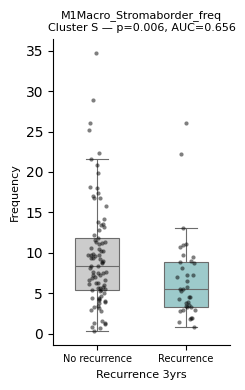

In [280]:
feature = "TumorNonproliferating_Tumorcore_HIFa"
cluster = 'D'

feature = "TumorNonproliferating_Tumorcore_pS6"
cluster = 'G'

feature = "Bcells_Tumorborder_freq"
cluster = 'T'

feature = "M1Macro_Stromaborder_freq"
cluster = 'S'

df_plot = freq_wide_image_flat[
    freq_wide_image_flat['ImageCluster'] == cluster
][[feature, 'Outcome']].dropna()

df_plot['Outcome'] = df_plot['Outcome'].astype(int)

fig, ax = plt.subplots(figsize=(2.5, 4))

sns.boxplot(data=df_plot, x='Outcome', y=feature,
            hue='Outcome',
            palette={0: '#CCCCCC', 1: CLUSTER_COLORS[cluster]},
            width=0.5, linewidth=0.8, fliersize=0, ax=ax)
sns.stripplot(data=df_plot, x='Outcome', y=feature,
              color='black', size=3, alpha=0.5, jitter=True, ax=ax)

from scipy.stats import mannwhitneyu
g0 = df_plot[df_plot['Outcome'] == 0][feature]
g1 = df_plot[df_plot['Outcome'] == 1][feature]
stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
auc = stat / (len(g0) * len(g1))
auc = max(auc, 1 - auc)  # always report > 0.5
print(len(g0))
print(len(g1))

ax.set_title(f'{feature}\nCluster {cluster} — p={p:.3f}, AUC={auc:.3f}', fontsize=8)
ax.set_xlabel('Recurrence 3yrs', fontsize=8)
ax.set_ylabel('Frequency', fontsize=8)
ax.set_xticklabels(['No recurrence', 'Recurrence'], fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "tmp", f"{feature}.pdf"))
plt.show()

# Stabl

In [38]:
import stabl.utils
importlib.reload(stabl.utils)
import stabl.pipelines_utils
importlib.reload(stabl.pipelines_utils)
import stabl.multi_omic_pipelinesNoe
importlib.reload(stabl.multi_omic_pipelinesNoe)
from stabl.multi_omic_pipelinesNoe import multi_omic_stabl_cv_noe


In [20]:
from pathlib import Path
from stabl.stablNoe import Stabl  # explicitly from stablNoe
from sklearn.linear_model import Lasso, ElasticNet, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from stabl.adaptive import ALogitLasso
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, GroupShuffleSplit, GridSearchCV, LeaveOneGroupOut
from stabl.multi_omic_pipelinesNoe import multi_omic_stabl_cv_noe 

inner_group_cv = GroupShuffleSplit(n_splits=25, test_size=0.2, random_state=42)
chosen_inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# ── 1. Build estimators dict ──────────────────────────────────────────────────
# Base penalized models wrapped in GridSearchCV (as the function expects)
# Lasso
lasso = LogisticRegression(penalty="l1", class_weight="balanced", max_iter=int(1e6), solver="liblinear", random_state=42)
lasso_cv = GridSearchCV(lasso, param_grid={"C": np.logspace(-2, 2, 30)}, scoring="roc_auc", cv=chosen_inner_cv, n_jobs=-1)

# ElasticNet
en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    class_weight='balanced',
    max_iter=int(1e3),
    random_state=42
)
en_cv = GridSearchCV(en, param_grid={"C": np.logspace(-2, 1, 5), "l1_ratio": [.5, .7, .9]}, scoring="roc_auc", cv=chosen_inner_cv, n_jobs=-1)

# ALasso
alasso = ALogitLasso(penalty="l1", solver="liblinear", max_iter=int(1e6), class_weight='balanced', random_state=42)
alasso_cv = GridSearchCV(alasso, scoring='roc_auc', param_grid={"C": np.logspace(-2, 2, 20)}, cv=chosen_inner_cv, n_jobs=-1)

xgb_base = XGBClassifier(
    n_estimators=100,
    verbosity=0,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False,
)

xgb_cv = GridSearchCV(
    xgb_base,
    param_grid={"reg_alpha": np.logspace(-2, 2, 10)},
    scoring="roc_auc",
    cv=chosen_inner_cv,
    n_jobs=-1
)

stabl = Stabl(
    base_estimator=lasso,
    n_bootstraps=1000,
    artificial_type="knockoff",
    artificial_proportion=1,
    replace=False,
    fdr_threshold_range=np.arange(0.1, 1, 0.01),
    sample_fraction=0.5,
    random_state=42,
    lambda_grid={"C": np.linspace(0.01, 1, 30)},
    verbose=1
)

stabl_alasso = clone(stabl).set_params(
    base_estimator=alasso,
    lambda_grid={"C": np.linspace(0.01, 10, 30)},
    verbose=1
)

stabl_en = clone(stabl).set_params(
    base_estimator=en,
    n_bootstraps=500,
    lambda_grid=[
        {"C": np.logspace(-3, -1, 10), "l1_ratio": [0.9]}
    ],
    verbose=1
)

stabl_xgb = clone(stabl).set_params(
    base_estimator=xgb_base,
    lambda_grid={"reg_alpha": np.logspace(-2, 2, 20)},
    n_bootstraps=200,
    importance_method="gain",
    verbose=1
)

estimators = {
    "lasso":       lasso_cv,
    "en":          en_cv,
    "alasso":      alasso_cv,   # same structure, STABL handles adaptive internally
    "stabl_lasso": stabl,
    "stabl_en":    stabl_en,
    "stabl_alasso": stabl_alasso,
    "stabl_xgb":   stabl_xgb,
    # "xgb":         GridSearchCV(
    #                    XGBClassifier(verbosity=0, eval_metric='logloss', scale_pos_weight = (y == 0).sum() / (y == 1).sum()),
    #                    param_grid={
    #                         'reg_alpha': np.logspace(-2, 2, 5),
    #                         'reg_lambda': np.logspace(-2, 2, 5),
    #                         'max_depth': [3, 5, 7],
    #                         'min_child_weight': [1, 5, 10],  # higher = more conservative, helps with imbalance
    #                     },
    #                    cv=5, scoring='roc_auc'
    #                ),
}

# ── 2. Models to run ──────────────────────────────────────────────────────────
models_to_run = ["STABL Lasso"]

# ── 3. Loop over clusters ─────────────────────────────────────────────────────
all_cluster_results = {}
clusters_to_plot = {'D', 'G', 'T', 'S'}

for cluster in clusters_to_plot:
    print(f"\n{'='*50}\nCluster {cluster}\n{'='*50}")

    cluster_features = results_df[
        results_df['Cluster'] == cluster
    ]['Feature'].unique().tolist()
    cluster_features = [f for f in cluster_features if f in feature_cols]

    subset = median_wide_filtered[
        median_wide_filtered['ImageCluster'] == cluster
    ][cluster_features + ['Casenumber', 'Outcome']].dropna(subset=['Outcome'])

    if subset.shape[0] < 20:
        print(f"  Too few samples ({subset.shape[0]}), skipping")
        continue

    X = subset[cluster_features].fillna(subset[cluster_features].median())
    y = subset['Outcome'].astype(int).rename('Outcome')  # keep as Series with name
    groups = subset['Casenumber'].rename('Casenumber')   # keep as Series

    # Single-omic: data_dict has just one entry
    data_dict = {f"cluster_{cluster}": X}

    save_path = Path(os.path.join(base_dir, "tmp", f"results/cluster_{cluster}"))

    predictions = multi_omic_stabl_cv_noe(
        data_dict=data_dict,
        y=y,
        outer_splitter=LeaveOneGroupOut(),
        estimators=estimators,
        task_type="binary",
        model_chosen="logit",   # final model on STABL-selected features
        models=models_to_run,
        save_path=save_path,
        importance_method="gain",
        outer_groups=groups,
        early_fusion=False,       # no-op with single omic anyway
        late_fusion=False,
    )

    all_cluster_results[cluster] = predictions
    print(f"Cluster {cluster} done. Results saved to {save_path}")


Cluster T
Stabl progress: 100%|██████████| 30/30 [00:50<00:00,  1.69s/it]
STABL Lasso finished on cluster_T (135 samples); 4 features selected
~~~~~~~~~~~~~~~~~~~
This fold: 4 features selected for STABL Lasso
~~~~~~~~~~~~~~~~~~~

Stabl progress: 100%|██████████| 30/30 [00:46<00:00,  1.55s/it]
STABL Lasso finished on cluster_T (135 samples); 14 features selected
~~~~~~~~~~~~~~~~~~~
This fold: 14 features selected for STABL Lasso
~~~~~~~~~~~~~~~~~~~

Stabl progress: 100%|██████████| 30/30 [00:47<00:00,  1.59s/it]
STABL Lasso finished on cluster_T (134 samples); 12 features selected
~~~~~~~~~~~~~~~~~~~
This fold: 12 features selected for STABL Lasso
~~~~~~~~~~~~~~~~~~~

Stabl progress: 100%|██████████| 30/30 [00:48<00:00,  1.61s/it]
STABL Lasso finished on cluster_T (134 samples); 10 features selected
~~~~~~~~~~~~~~~~~~~
This fold: 10 features selected for STABL Lasso
~~~~~~~~~~~~~~~~~~~

Stabl progress: 100%|██████████| 30/30 [00:48<00:00,  1.62s/it]
STABL Lasso finished on cluster_T (

ValueError: The 'groups' parameter should not be None.

In [52]:
cluster = 'D'

cluster_features = results_df[
    results_df['Cluster'] == cluster
]['Feature'].unique().tolist()
cluster_features = [f for f in cluster_features if f in feature_cols]

subset = median_wide_filtered[
    median_wide_filtered['ImageCluster'] == cluster
][cluster_features + ['Casenumber', 'Outcome']].dropna(subset=['Outcome'])

print(f"Shape: {subset.shape}")
print(f"Outcome distribution:\n{subset['Outcome'].value_counts()}\n")

# --- NA diagnostics ---
na_counts = subset[cluster_features].isna().sum()
na_pct    = subset[cluster_features].isna().mean() * 100

na_summary = (
    pd.DataFrame({'NA_count': na_counts, 'NA_pct': na_pct})
    .sort_values('NA_pct', ascending=False)
)

print(f"Features with >50% missing: {(na_summary['NA_pct'] > 50).sum()}")
print(f"Features with >20% missing: {(na_summary['NA_pct'] > 20).sum()}")
print(f"Features with any missing:  {(na_summary['NA_pct'] > 0).sum()}")
print(f"Features with no missing:   {(na_summary['NA_pct'] == 0).sum()}")
print(f"\nTop 20 most missing features:")
print(na_summary.head(20).to_string())

# --- Row-level missingness ---
row_na = subset[cluster_features].isna().sum(axis=1)
print(f"\nRow-level missingness:")
print(f"  Mean NAs per row:   {row_na.mean():.1f} / {len(cluster_features)}")
print(f"  Median NAs per row: {row_na.median():.1f}")
print(f"  Rows with >50% NA:  {(row_na > len(cluster_features)*0.5).sum()}")

Shape: (231, 593)
Outcome distribution:
Outcome
0.0    185
1.0     46
Name: count, dtype: int64

Features with >50% missing: 0
Features with >20% missing: 249
Features with any missing:  576
Features with no missing:   15

Top 20 most missing features:
                             NA_count     NA_pct
Feature                                         
Bcells_Tumorborder_NFkB           109  47.186147
Bcells_Tumorborder_Vista          109  47.186147
Bcells_Tumorborder_HLADR          109  47.186147
Bcells_Tumorborder_CD44           109  47.186147
Bcells_Tumorborder_pMK2           109  47.186147
Bcells_Tumorborder_STAT3          109  47.186147
Bcells_Tumorborder_pS6            109  47.186147
CD8Teff_Tumorcore_PD1             100  43.290043
CD8Teff_Tumorcore_NFkB            100  43.290043
CD8Teff_Tumorcore_PDL1            100  43.290043
CD8Teff_Tumorcore_Vista           100  43.290043
CD8Teff_Tumorcore_pMK2            100  43.290043
CD8Teff_Tumorcore_ICOS            100  43.290043
CD8Teff_Tumo

In [56]:
# Who are the 8 high-missingness images?
row_na = subset[cluster_features].isna().sum(axis=1)
high_na_images = subset[row_na > len(cluster_features) * 0.2][['Casenumber', 'Outcome']]
high_na_images['n_missing'] = row_na[row_na > len(cluster_features) * 0.2]
high_na_images['pct_missing'] = high_na_images['n_missing'] / len(cluster_features) * 100
print(high_na_images.sort_values('pct_missing', ascending=False))

Feature    Casenumber  Outcome  n_missing  pct_missing
Image                                                 
K33       K2016_10981      0.0        353    59.729272
T07      SHS-16-10270      0.0        326    55.160745
S67      SHS-16-00413      0.0        324    54.822335
S36      SHS-15-28366      0.0        320    54.145516
A28       K2009_11154      0.0        309    52.284264
...               ...      ...        ...          ...
T72      SHS-17-23824      0.0        127    21.489002
A05       K2009_23074      0.0        127    21.489002
M03       K2017_00053      0.0        126    21.319797
D26       K2011_24531      0.0        126    21.319797
S39      SHS-15-33864      1.0        123    20.812183

[76 rows x 4 columns]


In [57]:
for feat_thresh in [0.2, 0.3, 0.5]:
    for img_thresh in [0.2, 0.3, 0.5]:
        # Apply feature filter first
        na_pct_feat = subset[cluster_features].isna().mean()
        feats_kept  = na_pct_feat[na_pct_feat < feat_thresh].index.tolist()
        
        # Then apply image filter on remaining features
        na_pct_img  = subset[feats_kept].isna().mean(axis=1)
        imgs_kept   = na_pct_img[na_pct_img < img_thresh]
        imgs_dropped = subset.loc[~subset.index.isin(imgs_kept.index)]
        
        n_recur_lost = int(imgs_dropped['Outcome'].sum())
        
        print(f"feat<{feat_thresh*100:.0f}% & img<{img_thresh*100:.0f}%: "
              f"{len(feats_kept)} features, "
              f"{imgs_kept.shape[0]} images kept, "
              f"{len(imgs_dropped)} images dropped, "
              f"{n_recur_lost} recurrent lost")

feat<20% & img<20%: 342 features, 212 images kept, 19 images dropped, 3 recurrent lost
feat<20% & img<30%: 342 features, 222 images kept, 9 images dropped, 1 recurrent lost
feat<20% & img<50%: 342 features, 231 images kept, 0 images dropped, 0 recurrent lost
feat<30% & img<20%: 479 features, 184 images kept, 47 images dropped, 9 recurrent lost
feat<30% & img<30%: 479 features, 210 images kept, 21 images dropped, 2 recurrent lost
feat<30% & img<50%: 479 features, 230 images kept, 1 images dropped, 0 recurrent lost
feat<50% & img<20%: 591 features, 155 images kept, 76 images dropped, 12 recurrent lost
feat<50% & img<30%: 591 features, 192 images kept, 39 images dropped, 8 recurrent lost
feat<50% & img<50%: 591 features, 223 images kept, 8 images dropped, 1 recurrent lost


In [55]:
# How many cluster D images does each high-missingness patient have?
print("Cluster D image counts for high-missingness patients:")
for case in high_na_images['Casenumber']:
    case_images = subset[subset['Casenumber'] == case]
    n_total     = len(case_images)
    n_high_na   = (row_na[case_images.index] > len(cluster_features) * 0.5).sum()
    outcome     = case_images['Outcome'].iloc[0]
    print(f"  {case}: {n_total} cluster-D image(s), {n_high_na} high-NA, outcome={outcome}")

Cluster D image counts for high-missingness patients:
  K2009_11154: 3 cluster-D image(s), 1 high-NA, outcome=0.0
  K2013_21434: 1 cluster-D image(s), 1 high-NA, outcome=0.0
  K2015_33831: 1 cluster-D image(s), 1 high-NA, outcome=0.0
  K2016_10981: 1 cluster-D image(s), 1 high-NA, outcome=0.0
  SHS-14-19397: 2 cluster-D image(s), 1 high-NA, outcome=1.0
  SHS-15-28366: 3 cluster-D image(s), 1 high-NA, outcome=0.0
  SHS-16-00413: 3 cluster-D image(s), 1 high-NA, outcome=0.0
  SHS-16-10270: 1 cluster-D image(s), 1 high-NA, outcome=0.0
